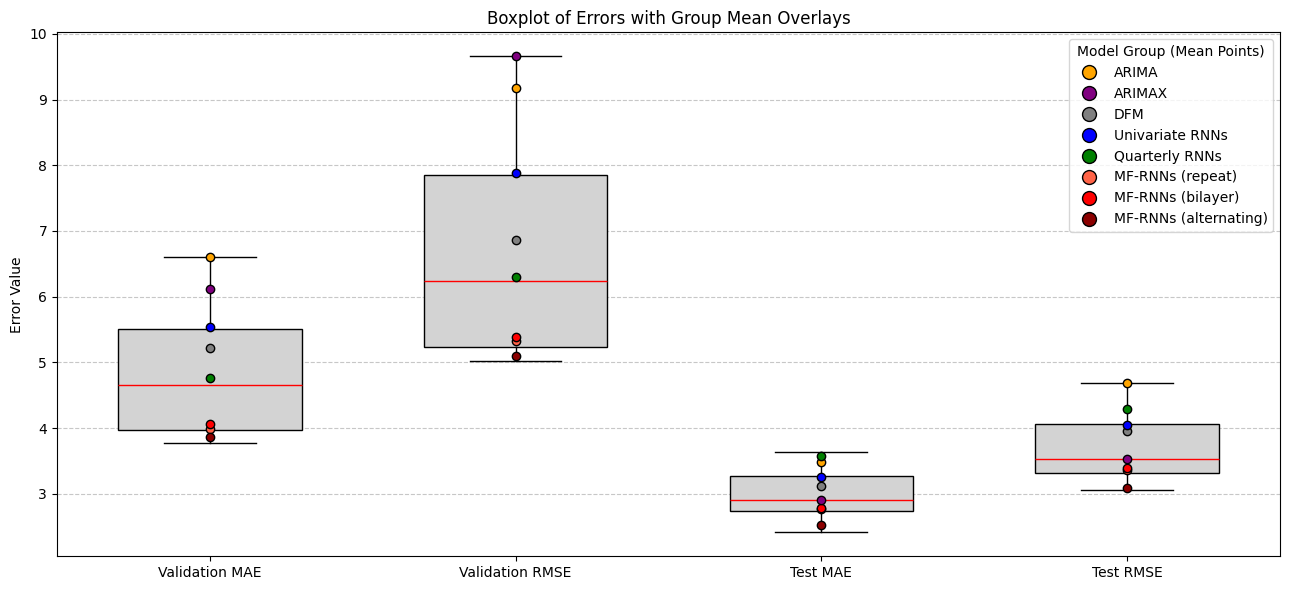

In [ ]:
# Re-import and rebuild data due to execution interruption

import matplotlib.pyplot as plt
import pandas as pd

# Recreate the dataset with revised groups including ARIMA
updated_data_latest = {
    'Model': ['ARIMA', 'Univariate GRU', 'Univariate LSTM',
              'ARIMAX', 'Quarterly GRU', 'Quarterly LSTM',
              'DFM', 'GRU-repeat', 'LSTM-repeat', 'GRU-bilayer', 'LSTM-bilayer', 'GRU-alternating', 'LSTM-alternating'],
    'MAE_Val': [6.61, 5.51, 5.57, 6.12, 4.66, 4.85, 5.22, 3.84, 4.12, 3.90, 4.21, 3.77, 3.97],
    'RMSE_Val': [9.17, 7.85, 7.92, 9.66, 6.23, 6.37, 6.86, 5.20, 5.46, 5.24, 5.54, 5.02, 5.16],
    'MAE_Test': [3.49, 3.24, 3.27, 2.90, 3.50, 3.64, 3.12, 2.74, 2.79, 2.88, 2.67, 2.64, 2.41],
    'RMSE_Test': [4.68, 4.03, 4.06, 3.53, 4.28, 4.29, 3.95, 3.28, 3.43, 3.47, 3.32, 3.12, 3.06],
    'Group': ['ARIMA', 'Univariate RNNs', 'Univariate RNNs',
              'ARIMAX', 'Quarterly RNNs', 'Quarterly RNNs',
              'DFM', 'MF-RNNs (alternate)', 'MF-RNNs (repeat)', 'MF-RNNs (bilayer)', 'MF-RNNs (bilayer)',
              'MF-RNNs (alternating)', 'MF-RNNs (alternating)']
}

df_latest_grouped = pd.DataFrame(updated_data_latest)

# Define new group order and color mapping
group_order = ['ARIMA', 'MF-RNNs (repeat)', 'MF-RNNs (bilayer)', 'MF-RNNs (alternating)',
               'DFM', 'Quarterly RNNs', 'ARIMAX', 'Univariate RNNs']

group_colors = {
    'ARIMA': 'orange',
    'ARIMAX': 'purple',
    'DFM': 'gray',
    'Univariate RNNs': 'blue',
    'Quarterly RNNs': 'green',   
    'MF-RNNs (repeat)': 'tomato',
    'MF-RNNs (bilayer)': 'red',
    'MF-RNNs (alternating)': 'darkred',
}

# Compute group means for plotting
group_means_updated = df_latest_grouped.groupby('Group')[['MAE_Val', 'RMSE_Val', 'MAE_Test', 'RMSE_Test']].mean()

# Prepare long format for overlaying mean points
metric_labels = ['Validation MAE', 'Validation RMSE', 'Test MAE', 'Test RMSE']
mean_overlay = []
for i, metric in enumerate(['MAE_Val', 'RMSE_Val', 'MAE_Test', 'RMSE_Test']):
    for group in group_order:
        mean_overlay.append({
            'Group': group,
            'Metric': metric_labels[i],
            'Mean_Error': group_means_updated.loc[group, metric]
        })

df_means_final = pd.DataFrame(mean_overlay)

# Plotting positions
positions = [1, 2, 3, 4]

plt.figure(figsize=(13, 6))

# Base boxplots
for j, metric in enumerate(['MAE_Val', 'RMSE_Val', 'MAE_Test', 'RMSE_Test']):
    plt.boxplot(df_latest_grouped[metric], positions=[positions[j]], widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor='lightgray'),
                medianprops=dict(color='red'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(markerfacecolor='black', marker='o', markersize=4, linestyle='none'))

# Overlay mean points by group
for group in group_order:
    subset = df_means_final[df_means_final['Group'] == group]
    for j, pos in enumerate(positions):
        y = subset.iloc[j]['Mean_Error']
        plt.scatter(pos, y, color=group_colors[group], label=group if j == 0 else "", zorder=3, edgecolor='black')

# Custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label=group,
                      markerfacecolor=color, markeredgecolor='black', markersize=10)
           for group, color in group_colors.items()]

plt.xticks(positions, metric_labels)
plt.ylabel("Error Value")
plt.title("Boxplot of Errors with Group Mean Overlays")
plt.legend(handles=handles, title="Model Group (Mean Points)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


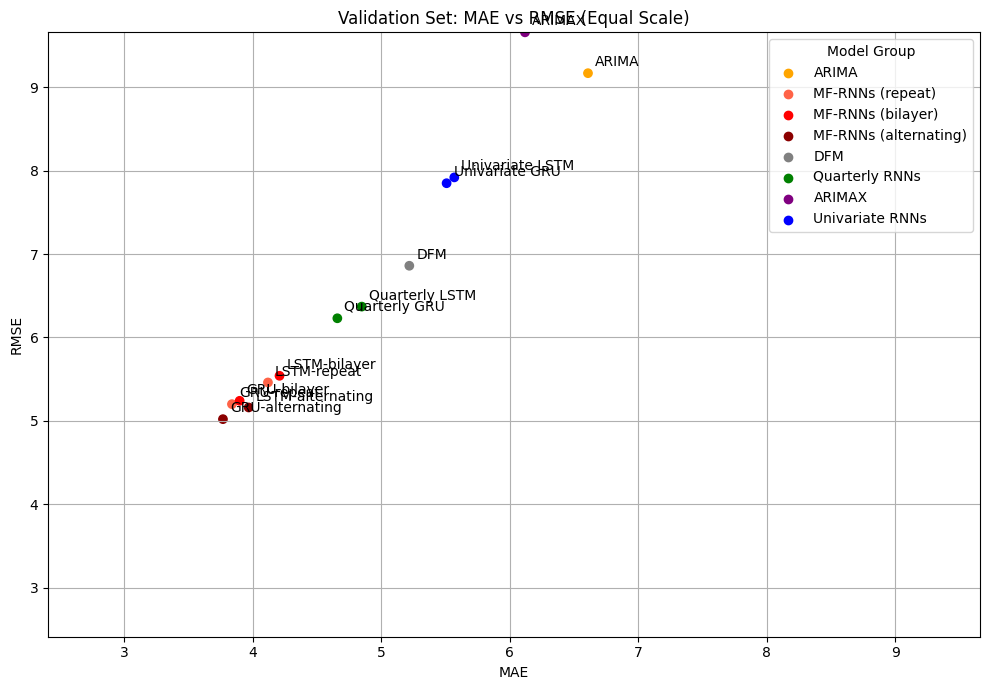

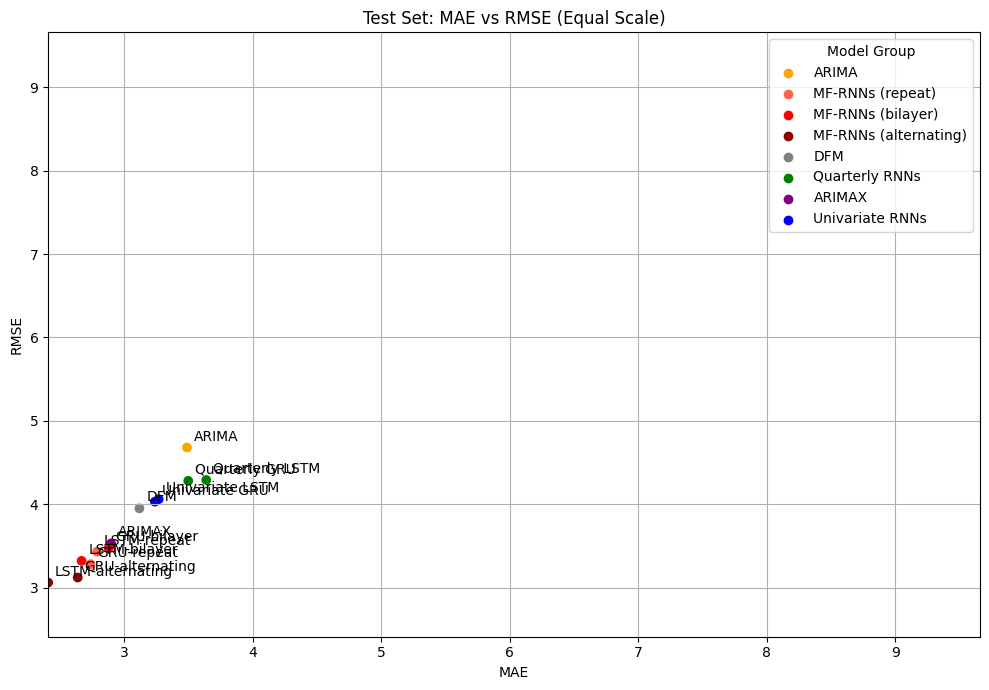

In [8]:
# Determine consistent min and max values across both MAE and RMSE for validation and test
x_min = min(df_latest_grouped['MAE_Val'].min(), df_latest_grouped['MAE_Test'].min())
x_max = max(df_latest_grouped['MAE_Val'].max(), df_latest_grouped['MAE_Test'].max())
y_min = min(df_latest_grouped['RMSE_Val'].min(), df_latest_grouped['RMSE_Test'].min())
y_max = max(df_latest_grouped['RMSE_Val'].max(), df_latest_grouped['RMSE_Test'].max())

# Determine overall min/max for consistent axis scale
overall_min = min(x_min, y_min)
overall_max = max(x_max, y_max)

# Validation Set Plot (MAE vs RMSE) with equal axis scales
plt.figure(figsize=(10, 7))
plt.scatter(df_latest_grouped['MAE_Val'], df_latest_grouped['RMSE_Val'], c=df_latest_grouped['Color'])

for i in range(len(df_latest_grouped)):
    plt.annotate(df_latest_grouped['Model'][i],
                 (df_latest_grouped['MAE_Val'][i], df_latest_grouped['RMSE_Val'][i]),
                 textcoords="offset points", xytext=(5, 5), ha='left')

for group, color in color_map.items():
    plt.scatter([], [], c=color, label=group)

plt.title('Validation Set: MAE vs RMSE (Equal Scale)')
plt.xlabel('MAE')
plt.ylabel('RMSE')
plt.xlim(overall_min, overall_max)
plt.ylim(overall_min, overall_max)
plt.legend(title='Model Group')
plt.grid(True)
plt.tight_layout()
plt.show()

# Test Set Plot (MAE vs RMSE) with equal axis scales
plt.figure(figsize=(10, 7))
plt.scatter(df_latest_grouped['MAE_Test'], df_latest_grouped['RMSE_Test'], c=df_latest_grouped['Color'])

for i in range(len(df_latest_grouped)):
    plt.annotate(df_latest_grouped['Model'][i],
                 (df_latest_grouped['MAE_Test'][i], df_latest_grouped['RMSE_Test'][i]),
                 textcoords="offset points", xytext=(5, 5), ha='left')

for group, color in color_map.items():
    plt.scatter([], [], c=color, label=group)

plt.title('Test Set: MAE vs RMSE (Equal Scale)')
plt.xlabel('MAE')
plt.ylabel('RMSE')
plt.xlim(overall_min, overall_max)
plt.ylim(overall_min, overall_max)
plt.legend(title='Model Group')
plt.grid(True)
plt.tight_layout()
plt.show()


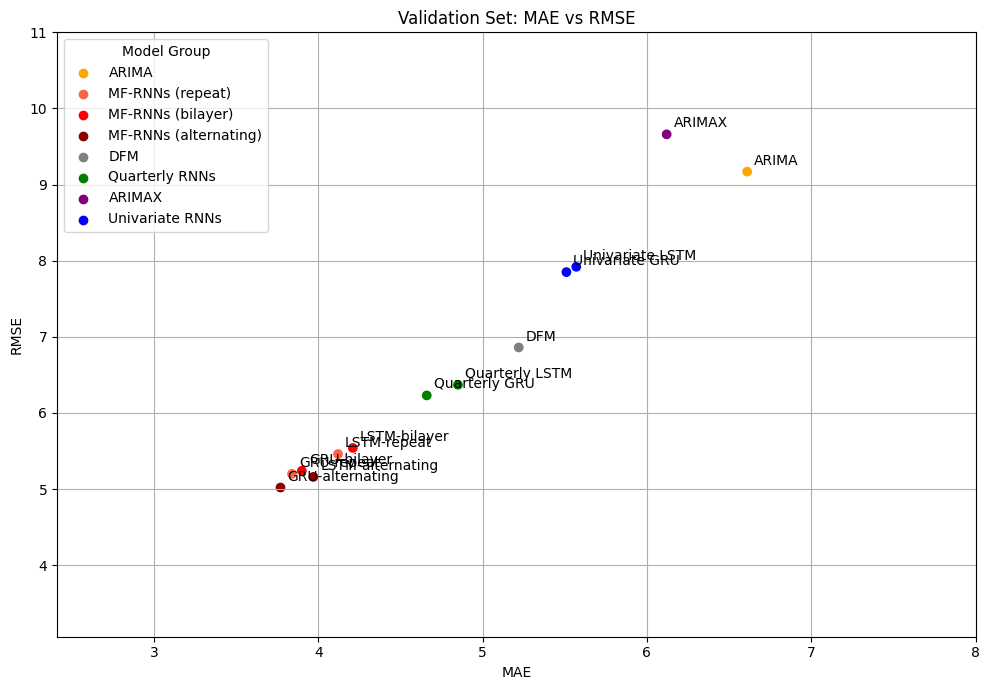

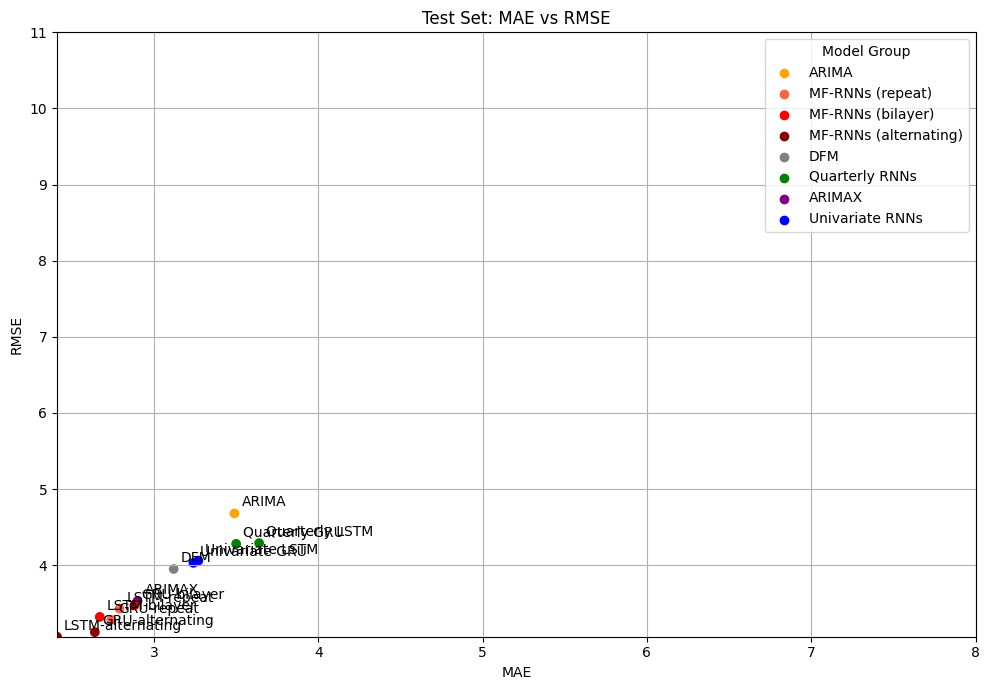

In [131]:
# Determine consistent min and max values across both MAE and RMSE for validation and test
x_min = min(df_latest_grouped['MAE_Val'].min(), df_latest_grouped['MAE_Test'].min())
x_max = 8.0  # Setting x-axis limit to 8 as requested
y_min = min(df_latest_grouped['RMSE_Val'].min(), df_latest_grouped['RMSE_Test'].min())
y_max = 11.0  # Setting y-axis limit to 11 as requested

# Validation Set Plot (MAE vs RMSE) with requested axis scales
plt.figure(figsize=(10, 7))
plt.scatter(df_latest_grouped['MAE_Val'], df_latest_grouped['RMSE_Val'], c=df_latest_grouped['Color'])

for i in range(len(df_latest_grouped)):
    plt.annotate(df_latest_grouped['Model'][i],
                 (df_latest_grouped['MAE_Val'][i], df_latest_grouped['RMSE_Val'][i]),
                 textcoords="offset points", xytext=(5, 5), ha='left')

for group, color in color_map.items():
    plt.scatter([], [], c=color, label=group)

plt.title('Validation Set: MAE vs RMSE')
plt.xlabel('MAE')
plt.ylabel('RMSE')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend(title='Model Group')
plt.grid(True)
plt.tight_layout()
plt.show()

# Test Set Plot (MAE vs RMSE) with requested axis scales
plt.figure(figsize=(10, 7))
plt.scatter(df_latest_grouped['MAE_Test'], df_latest_grouped['RMSE_Test'], c=df_latest_grouped['Color'])

for i in range(len(df_latest_grouped)):
    plt.annotate(df_latest_grouped['Model'][i],
                 (df_latest_grouped['MAE_Test'][i], df_latest_grouped['RMSE_Test'][i]),
                 textcoords="offset points", xytext=(5, 5), ha='left')

for group, color in color_map.items():
    plt.scatter([], [], c=color, label=group)

plt.title('Test Set: MAE vs RMSE')
plt.xlabel('MAE')
plt.ylabel('RMSE')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend(title='Model Group')
plt.grid(True)
plt.tight_layout()
plt.show()

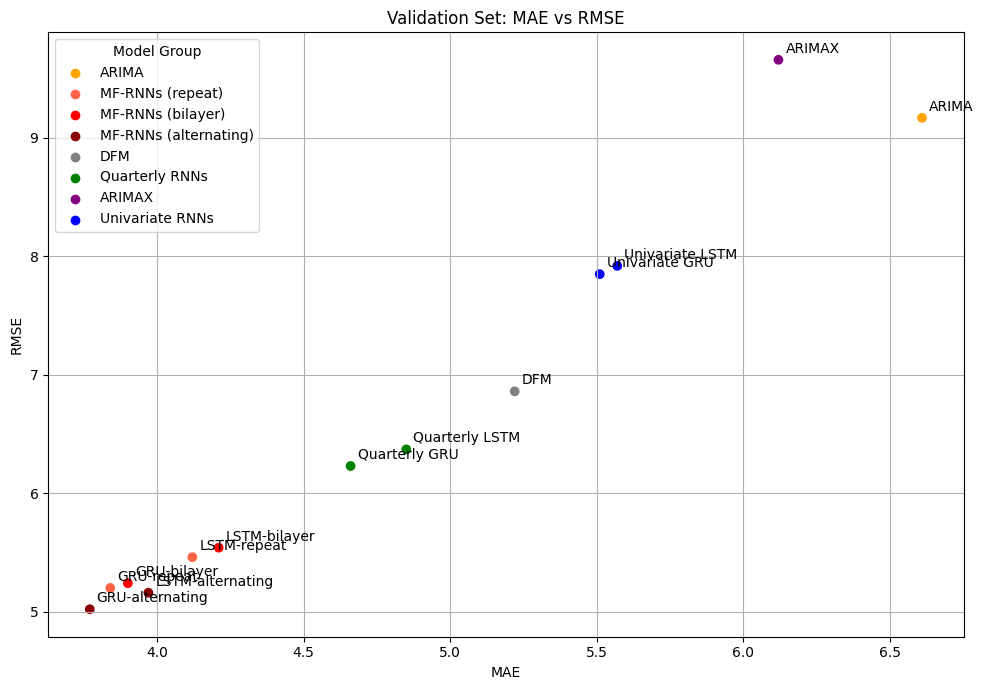

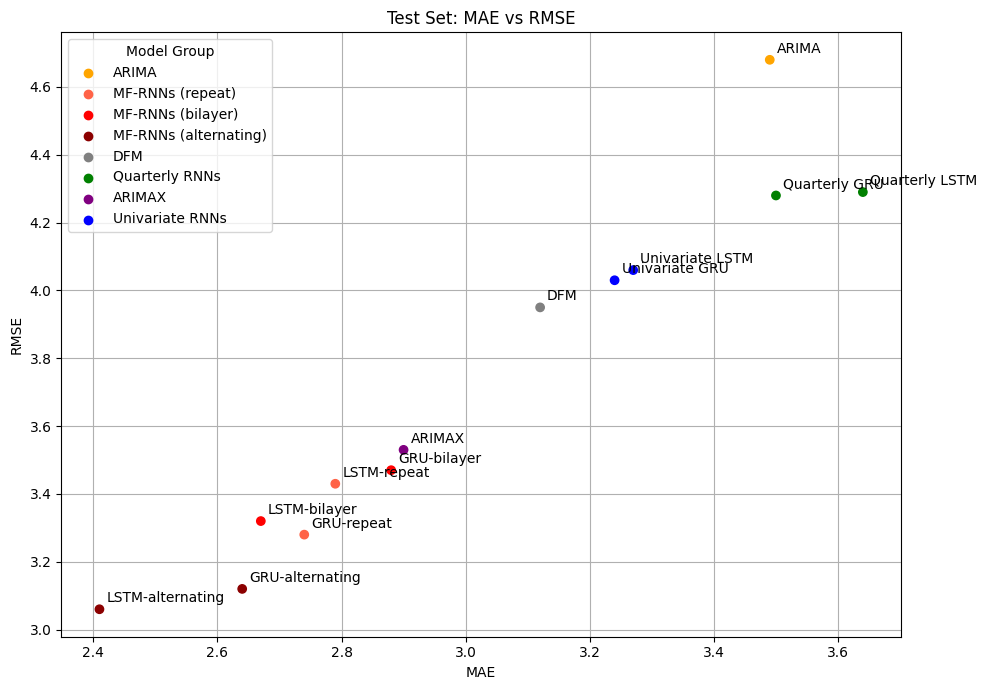

In [7]:
# Create scatter plots for the updated baseline (ARIMA) along with all groups for comparison

# Filter necessary data
color_map = {
    'ARIMA': 'orange',
    'MF-RNNs (repeat)': 'tomato',
    'MF-RNNs (bilayer)': 'red',
    'MF-RNNs (alternating)': 'darkred',
    'DFM': 'gray',
    'Quarterly RNNs': 'green',
    'ARIMAX': 'purple',
    'Univariate RNNs': 'blue'
}
df_latest_grouped['Color'] = df_latest_grouped['Group'].map(color_map)

# Validation Set Plot: MAE vs RMSE
plt.figure(figsize=(10, 7))
plt.scatter(df_latest_grouped['MAE_Val'], df_latest_grouped['RMSE_Val'], c=df_latest_grouped['Color'])

# Annotate points
for i in range(len(df_latest_grouped)):
    plt.annotate(df_latest_grouped['Model'][i],
                 (df_latest_grouped['MAE_Val'][i], df_latest_grouped['RMSE_Val'][i]),
                 textcoords="offset points", xytext=(5, 5), ha='left')

# Custom legend
for group, color in color_map.items():
    plt.scatter([], [], c=color, label=group)

plt.title('Validation Set: MAE vs RMSE')
plt.xlabel('MAE')
plt.ylabel('RMSE')
plt.legend(title='Model Group')
plt.grid(True)
plt.tight_layout()
plt.show()

# Test Set Plot: MAE vs RMSE
plt.figure(figsize=(10, 7))
plt.scatter(df_latest_grouped['MAE_Test'], df_latest_grouped['RMSE_Test'], c=df_latest_grouped['Color'])

# Annotate points
for i in range(len(df_latest_grouped)):
    plt.annotate(df_latest_grouped['Model'][i],
                 (df_latest_grouped['MAE_Test'][i], df_latest_grouped['RMSE_Test'][i]),
                 textcoords="offset points", xytext=(5, 5), ha='left')

# Custom legend
for group, color in color_map.items():
    plt.scatter([], [], c=color, label=group)

plt.title('Test Set: MAE vs RMSE')
plt.xlabel('MAE')
plt.ylabel('RMSE')
plt.legend(title='Model Group')
plt.grid(True)
plt.tight_layout()
plt.show()


As 

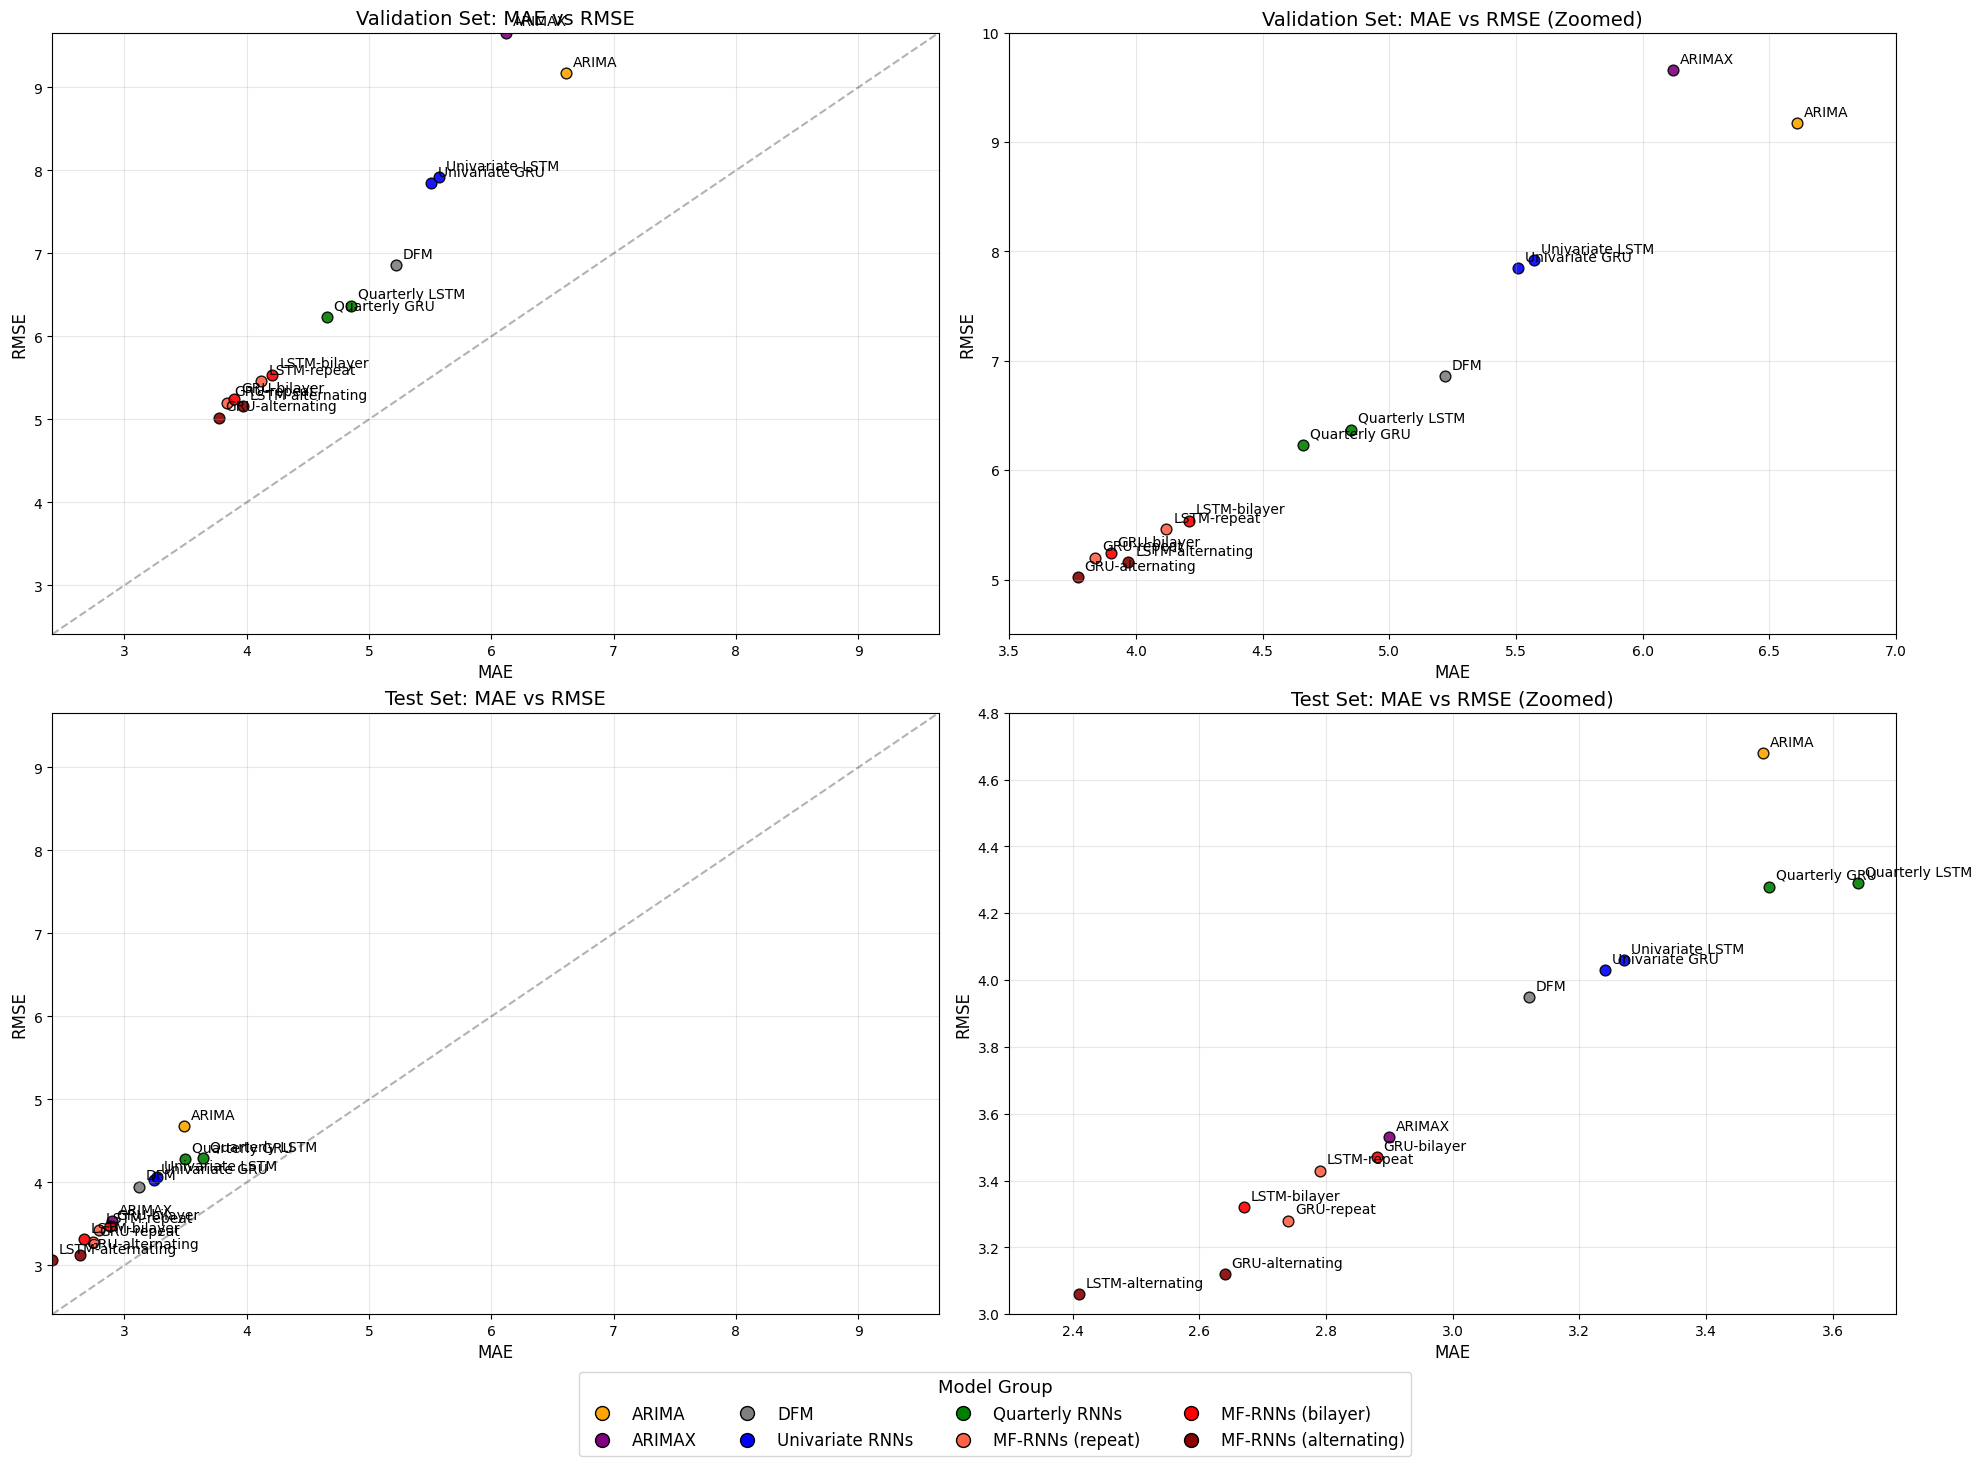

In [135]:
# Create a 2x2 grid of plots showing MAE vs RMSE for validation and test sets
fig, axs = plt.subplots(2, 2, figsize=(20, 15))

# Define common settings
scatter_size = 60
alpha_val = 0.9

# Determine consistent min and max values for the left plots
left_x_min = min(df_latest_grouped['MAE_Val'].min(), df_latest_grouped['MAE_Test'].min())
left_x_max = max(df_latest_grouped['MAE_Val'].max(), df_latest_grouped['MAE_Test'].max())
left_y_min = min(df_latest_grouped['RMSE_Val'].min(), df_latest_grouped['RMSE_Test'].min())
left_y_max = max(df_latest_grouped['RMSE_Val'].max(), df_latest_grouped['RMSE_Test'].max())

# Make sure both plots have the same range on both axes
left_min = min(left_x_min, left_y_min)
left_max = max(left_x_max, left_y_max)

# 1. Upper Left: Validation MAE vs RMSE (with style from cell 3)
ax = axs[0, 0]
# Use color mapping from cell 3
for i in range(len(df_latest_grouped)):
    group = df_latest_grouped['Group'][i]
    color = group_colors[group]
    ax.scatter(df_latest_grouped['MAE_Val'][i], df_latest_grouped['RMSE_Val'][i], 
               color=color, s=scatter_size, alpha=alpha_val, edgecolor='black')
    ax.annotate(df_latest_grouped['Model'][i], 
                (df_latest_grouped['MAE_Val'][i], df_latest_grouped['RMSE_Val'][i]),
                textcoords="offset points", xytext=(5, 5), ha='left')
ax.set_title('Validation Set: MAE vs RMSE', fontsize=14)
ax.set_xlabel('MAE', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xlim(left_min, left_max)
ax.set_ylim(left_min, left_max)
ax.grid(True, alpha=0.3)

# 2. Upper Right: Validation MAE vs RMSE zoomed
ax = axs[0, 1]
for i in range(len(df_latest_grouped)):
    group = df_latest_grouped['Group'][i]
    color = group_colors[group]
    ax.scatter(df_latest_grouped['MAE_Val'][i], df_latest_grouped['RMSE_Val'][i], 
               color=color, s=scatter_size, alpha=alpha_val, edgecolor='black')
    ax.annotate(df_latest_grouped['Model'][i], 
                (df_latest_grouped['MAE_Val'][i], df_latest_grouped['RMSE_Val'][i]),
                textcoords="offset points", xytext=(5, 5), ha='left')
ax.set_title('Validation Set: MAE vs RMSE (Zoomed)', fontsize=14)
ax.set_xlabel('MAE', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xlim(3.5, 7.0)  # Adjusted zoom level for better visualization
ax.set_ylim(4.5, 10.0)
ax.grid(True, alpha=0.3)

# 3. Lower Left: Test MAE vs RMSE (with style from cell 3)
ax = axs[1, 0]
for i in range(len(df_latest_grouped)):
    group = df_latest_grouped['Group'][i]
    color = group_colors[group]
    ax.scatter(df_latest_grouped['MAE_Test'][i], df_latest_grouped['RMSE_Test'][i], 
               color=color, s=scatter_size, alpha=alpha_val, edgecolor='black')
    ax.annotate(df_latest_grouped['Model'][i], 
                (df_latest_grouped['MAE_Test'][i], df_latest_grouped['RMSE_Test'][i]),
                textcoords="offset points", xytext=(5, 5), ha='left')
ax.set_title('Test Set: MAE vs RMSE', fontsize=14)
ax.set_xlabel('MAE', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xlim(left_min, left_max)
ax.set_ylim(left_min, left_max)
ax.grid(True, alpha=0.3)

# 4. Lower Right: Test MAE vs RMSE zoomed
ax = axs[1, 1]
for i in range(len(df_latest_grouped)):
    group = df_latest_grouped['Group'][i]
    color = group_colors[group]
    ax.scatter(df_latest_grouped['MAE_Test'][i], df_latest_grouped['RMSE_Test'][i], 
               color=color, s=scatter_size, alpha=alpha_val, edgecolor='black')
    ax.annotate(df_latest_grouped['Model'][i], 
                (df_latest_grouped['MAE_Test'][i], df_latest_grouped['RMSE_Test'][i]),
                textcoords="offset points", xytext=(5, 5), ha='left')
ax.set_title('Test Set: MAE vs RMSE (Zoomed)', fontsize=14)
ax.set_xlabel('MAE', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xlim(2.3, 3.7)  # Adjusted zoom level for better visualization
ax.set_ylim(3.0, 4.8)
ax.grid(True, alpha=0.3)

# Add diagonal reference line on left plots
for ax in [axs[0,0], axs[1,0]]:
    ax.plot([left_min, left_max], [left_min, left_max], 'k--', alpha=0.3)

# Create a single legend for the entire figure
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                      markeredgecolor='black', markersize=10, label=group) 
           for group, color in group_colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.02), 
           title="Model Group", fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)  # Adjust to make room for the legend
plt.show()

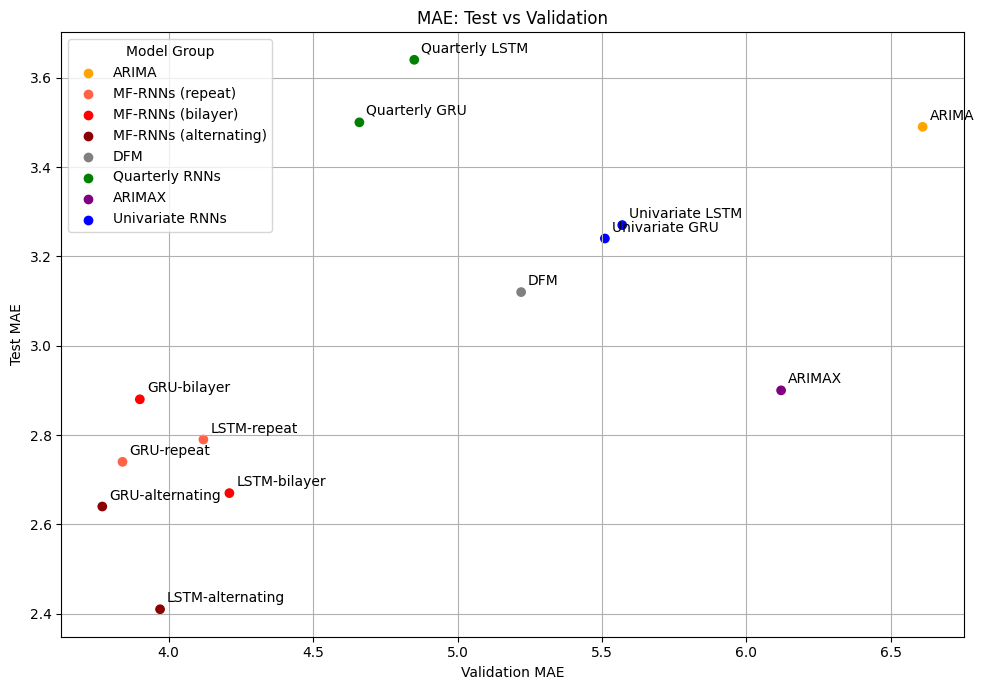

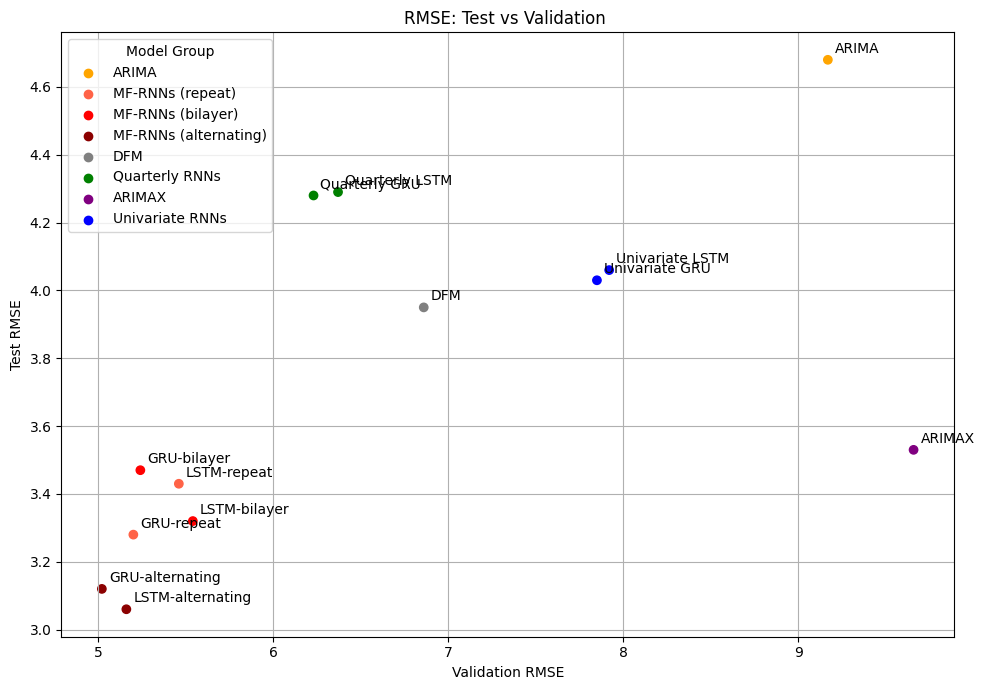

In [43]:
# Plot 1: MAE (Validation vs Test)
plt.figure(figsize=(10, 7))
plt.scatter(df_latest_grouped['MAE_Val'], df_latest_grouped['MAE_Test'], c=df_latest_grouped['Color'])

# Annotate each model
for i in range(len(df_latest_grouped)):
    plt.annotate(df_latest_grouped['Model'][i],
                 (df_latest_grouped['MAE_Val'][i], df_latest_grouped['MAE_Test'][i]),
                 textcoords="offset points", xytext=(5, 5), ha='left')

# Custom legend
for group, color in color_map.items():
    plt.scatter([], [], c=color, label=group)

plt.title('MAE: Test vs Validation')
plt.xlabel('Validation MAE')
plt.ylabel('Test MAE')
plt.legend(title='Model Group')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: RMSE (Validation vs Test)
plt.figure(figsize=(10, 7))
plt.scatter(df_latest_grouped['RMSE_Val'], df_latest_grouped['RMSE_Test'], c=df_latest_grouped['Color'])

# Annotate each model
for i in range(len(df_latest_grouped)):
    plt.annotate(df_latest_grouped['Model'][i],
                 (df_latest_grouped['RMSE_Val'][i], df_latest_grouped['RMSE_Test'][i]),
                 textcoords="offset points", xytext=(5, 5), ha='left')

# Custom legend
for group, color in color_map.items():
    plt.scatter([], [], c=color, label=group)

plt.title('RMSE: Test vs Validation ')
plt.xlabel('Validation RMSE')
plt.ylabel('Test RMSE')
plt.legend(title='Model Group')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Load test result datasets
dfm_result_test = pd.read_csv("results/loss_plot 2025-05-18 22h03m28s dfm/test idx=0 dfm.csv", parse_dates=['Unnamed: 0'])
alternate_lstm_result_test = pd.read_csv("results/loss_plot 2025-05-18 21h33m36s LSTM-alternate/test idx=2 LSTM-alternate.csv", parse_dates=['Unnamed: 0'])
quarterly_gru_result_test = pd.read_csv("results/loss_plot 2025-05-18 21h34m00s Quarterly GRU/test idx=2 Quarterly GRU.csv", parse_dates=['Unnamed: 0'])

# Set the date column as index
dfm_result_test.set_index('Unnamed: 0', inplace=True)
alternate_lstm_result_test.set_index('Unnamed: 0', inplace=True)
quarterly_gru_result_test.set_index('Unnamed: 0', inplace=True)

# Rename the index for clarity
dfm_result_test.index.name = 'date'
alternate_lstm_result_test.index.name = 'date'
quarterly_gru_result_test.index.name = 'date'

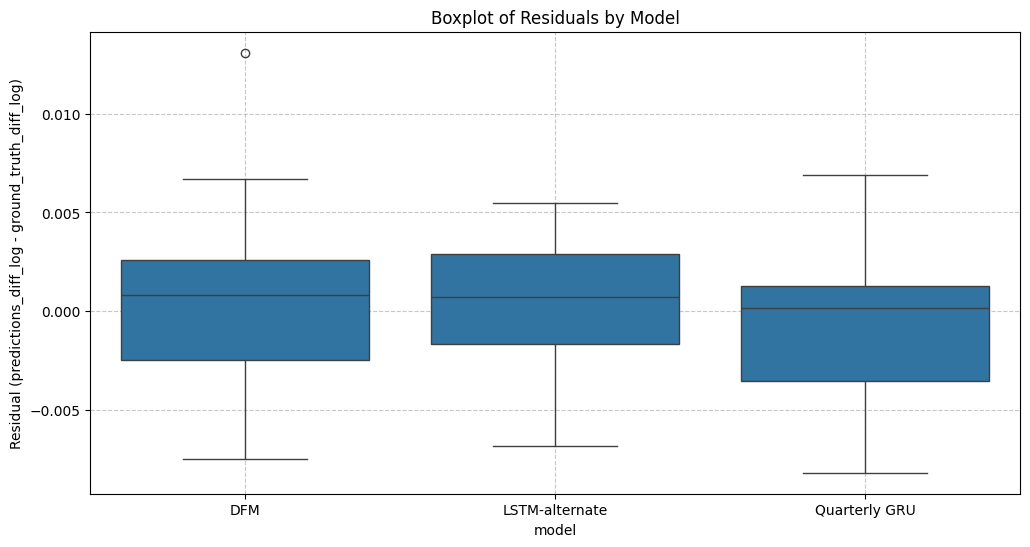

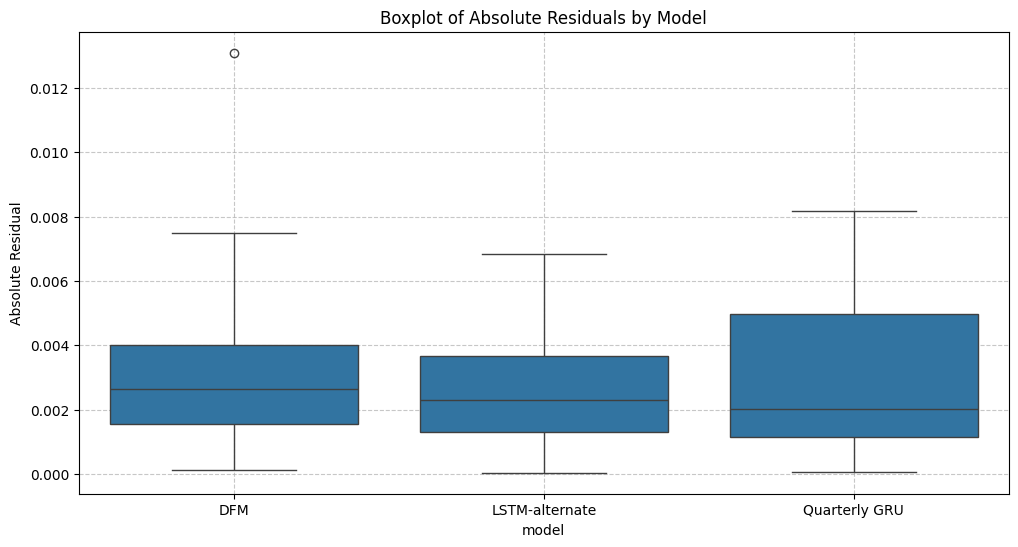

Paired t-test results (using absolute residuals):
LSTM-alternate vs Quarterly GRU: t-stat = -1.6408, p-value = 0.1113
LSTM-alternate vs DFM: t-stat = -1.8621, p-value = 0.0724

Interpretation (α = 0.05):
LSTM-alternate is not significantly different from Quarterly GRU
LSTM-alternate is not significantly different from DFM

Absolute Residual Statistics:
DFM: Mean = 0.0033, Median = 0.0026, Std = 0.0026
LSTM-alternate: Mean = 0.0024, Median = 0.0023, Std = 0.0016
Quarterly GRU: Mean = 0.0031, Median = 0.0020, Std = 0.0026


In [40]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

# First, calculate the residuals on the diff_log scale for each model
# and ensure we only use dates that exist in all three datasets

# Process each dataframe to extract dates and calculate residuals
def prepare_data(df, model_name):
    # Ensure the index is datetime format if it's not already
    if not isinstance(df.index, pd.DatetimeIndex):
        # Check if date exists as column and should be converted to index
        if 'date' in df.columns:
            df = df.set_index('date')
        elif 'Date' in df.columns:
            df = df.set_index('Date')
        df.index = pd.to_datetime(df.index)
        
    # Calculate residuals (prediction - ground_truth)
    df['residual'] = df['predictions_diff_log'] - df['ground_truth_diff_log']
    df['abs_residual'] = abs(df['residual'])
    
    # Add model name for identification
    df['model'] = model_name
    
    return df

# Process each dataset
dfm_data = prepare_data(dfm_result_test, 'DFM')
lstm_alt_data = prepare_data(alternate_lstm_result_test, 'LSTM-alternate')
quarterly_gru_data = prepare_data(quarterly_gru_result_test, 'Quarterly GRU')

# Find common dates across all datasets using index intersection
common_dates = dfm_data.index.intersection(lstm_alt_data.index).intersection(quarterly_gru_data.index)

# Filter datasets to include only common dates
dfm_filtered = dfm_data.loc[common_dates]
lstm_alt_filtered = lstm_alt_data.loc[common_dates]
qgru_filtered = quarterly_gru_data.loc[common_dates]

# Reset indices to convert date to column for easier plotting
dfm_filtered_plot = dfm_filtered.reset_index()
lstm_alt_filtered_plot = lstm_alt_filtered.reset_index()
qgru_filtered_plot = qgru_filtered.reset_index()

# Combine all datasets for plotting
all_data = pd.concat([dfm_filtered_plot, lstm_alt_filtered_plot, qgru_filtered_plot])

# 1. Create boxplots of residuals for each model
plt.figure(figsize=(12, 6))
sns.boxplot(x='model', y='residual', data=all_data)
plt.title('Boxplot of Residuals by Model')
plt.ylabel('Residual (predictions_diff_log - ground_truth_diff_log)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Create boxplots of absolute residuals
plt.figure(figsize=(12, 6))
sns.boxplot(x='model', y='abs_residual', data=all_data)
plt.title('Boxplot of Absolute Residuals by Model')
plt.ylabel('Absolute Residual')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Perform paired t-tests
# For statistical tests, keep the dataframes aligned by using the common dates
# No need to sort as we already filtered by the same common_dates

# Test 1: LSTM-alternate vs Quarterly GRU
t_stat_lstm_vs_gru, p_value_lstm_vs_gru = stats.ttest_rel(
    lstm_alt_filtered['abs_residual'], 
    qgru_filtered['abs_residual']
)

# Test 2: LSTM-alternate vs DFM
t_stat_lstm_vs_dfm, p_value_lstm_vs_dfm = stats.ttest_rel(
    lstm_alt_filtered['abs_residual'], 
    dfm_filtered['abs_residual']
)

# Print the results of statistical tests
print("Paired t-test results (using absolute residuals):")
print(f"LSTM-alternate vs Quarterly GRU: t-stat = {t_stat_lstm_vs_gru:.4f}, p-value = {p_value_lstm_vs_gru:.4f}")
print(f"LSTM-alternate vs DFM: t-stat = {t_stat_lstm_vs_dfm:.4f}, p-value = {p_value_lstm_vs_dfm:.4f}")

# Interpretation of p-values
alpha = 0.05
print("\nInterpretation (α = 0.05):")
print(f"LSTM-alternate is {'significantly' if p_value_lstm_vs_gru < alpha else 'not significantly'} different from Quarterly GRU")
print(f"LSTM-alternate is {'significantly' if p_value_lstm_vs_dfm < alpha else 'not significantly'} different from DFM")

# Additional statistics for absolute residuals
models = ['DFM', 'LSTM-alternate', 'Quarterly GRU']
abs_residuals = [dfm_filtered['abs_residual'], lstm_alt_filtered['abs_residual'], qgru_filtered['abs_residual']]

print("\nAbsolute Residual Statistics:")
for model, res in zip(models, abs_residuals):
    print(f"{model}: Mean = {res.mean():.4f}, Median = {res.median():.4f}, Std = {res.std():.4f}")

DFM dates: [Timestamp('2011-06-01 00:00:00'), Timestamp('2011-07-01 00:00:00'), Timestamp('2011-08-01 00:00:00'), Timestamp('2011-09-01 00:00:00'), Timestamp('2011-10-01 00:00:00'), Timestamp('2011-11-01 00:00:00'), Timestamp('2011-12-01 00:00:00'), Timestamp('2012-01-01 00:00:00'), Timestamp('2012-02-01 00:00:00'), Timestamp('2012-03-01 00:00:00'), Timestamp('2012-04-01 00:00:00'), Timestamp('2012-05-01 00:00:00'), Timestamp('2012-06-01 00:00:00'), Timestamp('2012-07-01 00:00:00'), Timestamp('2012-08-01 00:00:00'), Timestamp('2012-09-01 00:00:00'), Timestamp('2012-10-01 00:00:00'), Timestamp('2012-11-01 00:00:00'), Timestamp('2012-12-01 00:00:00'), Timestamp('2013-01-01 00:00:00'), Timestamp('2013-02-01 00:00:00'), Timestamp('2013-03-01 00:00:00'), Timestamp('2013-04-01 00:00:00'), Timestamp('2013-05-01 00:00:00'), Timestamp('2013-06-01 00:00:00'), Timestamp('2013-07-01 00:00:00'), Timestamp('2013-08-01 00:00:00'), Timestamp('2013-09-01 00:00:00'), Timestamp('2013-10-01 00:00:00'), Ti

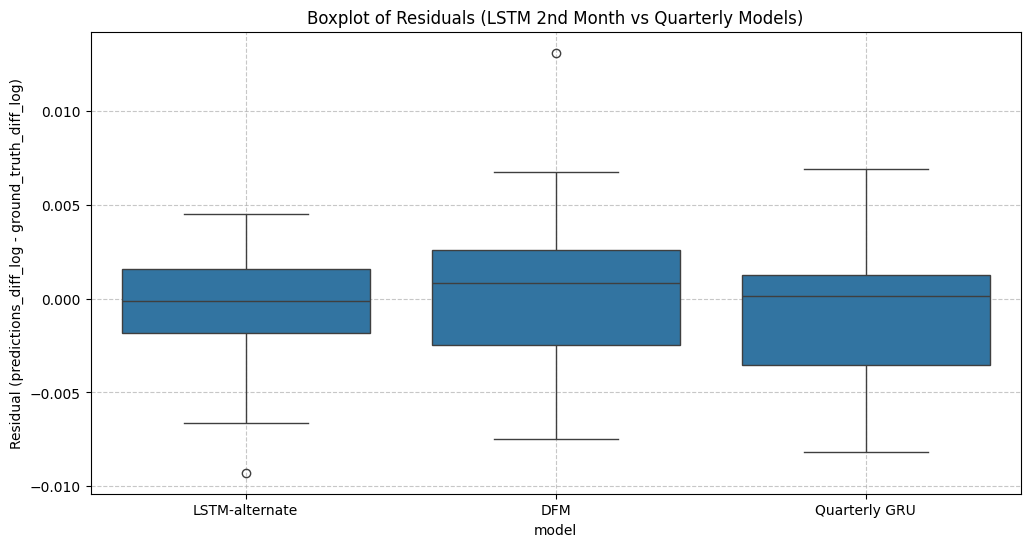

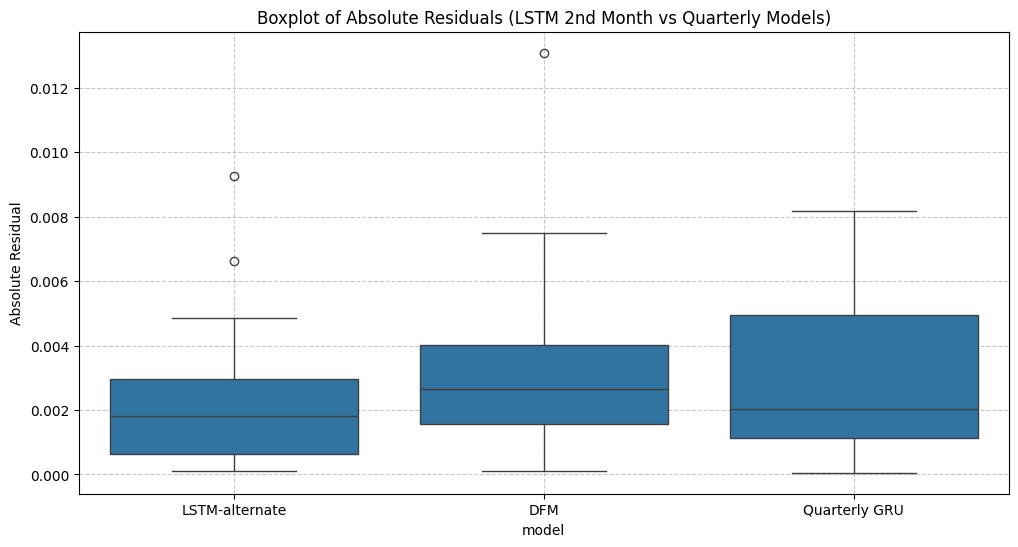

Paired t-test results (2nd month predictions):
LSTM-alternate vs Quarterly GRU: t-stat = -1.8280, p-value = 0.0775
LSTM-alternate vs DFM: t-stat = -1.8332, p-value = 0.0767

Interpretation (α = 0.05):
LSTM-alternate (2nd month) is not significantly different from Quarterly GRU
LSTM-alternate (2nd month) is not significantly different from DFM

Absolute Residual Statistics (2nd Month):
DFM: Mean = 0.0033, Median = 0.0026, Std = 0.0026
LSTM-alternate (2nd Month): Mean = 0.0022, Median = 0.0018, Std = 0.0021
Quarterly GRU: Mean = 0.0031, Median = 0.0020, Std = 0.0026


In [41]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

# Process each dataframe to extract dates and calculate residuals
def prepare_data(df, model_name):
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        
    # Calculate residuals (prediction - ground_truth)
    df['residual'] = df['predictions_diff_log'] - df['ground_truth_diff_log']
    df['abs_residual'] = abs(df['residual'])
    df['model'] = model_name
    
    return df

# Process each dataset
dfm_data = prepare_data(dfm_result_test.copy(), 'DFM')
lstm_alt_data_original = prepare_data(alternate_lstm_result_test.copy(), 'LSTM-alternate')
quarterly_gru_data = prepare_data(quarterly_gru_result_test.copy(), 'Quarterly GRU')

# Print the unique dates to debug
print("DFM dates:", sorted(dfm_data.index))
print("LSTM-alternate dates:", sorted(lstm_alt_data_original.index))
print("Quarterly GRU dates:", sorted(quarterly_gru_data.index))

# Filter LSTM alternate dataset to get only 2nd month predictions
# Second months are April, July, October, January (months 4, 7, 10, 1)
second_months = [4, 7, 10, 1]
lstm_alt_data_second = lstm_alt_data_original[lstm_alt_data_original.index.month.isin(second_months)]

# For each second month prediction from LSTM, find the corresponding preceding
# quarter-end date that the quarterly models would have used
lstm_dates = []
quarterly_dates = []

for date in sorted(lstm_alt_data_second.index):
    # April (4) corresponds to March (3)
    if date.month == 4:
        q_date = pd.Timestamp(date.year, 3, 31)
    # July (7) corresponds to June (6)
    elif date.month == 7:
        q_date = pd.Timestamp(date.year, 6, 30)
    # October (10) corresponds to September (9)
    elif date.month == 10:
        q_date = pd.Timestamp(date.year, 9, 30)
    # January (1) corresponds to previous year's December (12)
    elif date.month == 1:
        q_date = pd.Timestamp(date.year-1, 12, 31)
    
    # Adjust to actual dates in DFM and Quarterly GRU datasets
    # Find the closest available date before or at q_date
    dfm_available_dates = [d for d in dfm_data.index if d <= q_date]
    qgru_available_dates = [d for d in quarterly_gru_data.index if d <= q_date]
    
    if dfm_available_dates and qgru_available_dates:
        dfm_closest = max(dfm_available_dates)
        qgru_closest = max(qgru_available_dates)
        
        # Only include if both models have a valid date
        if dfm_closest == qgru_closest:
            lstm_dates.append(date)
            quarterly_dates.append(dfm_closest)

# If we have matching dates
if lstm_dates and quarterly_dates:
    # Get the matched data
    lstm_aligned = lstm_alt_data_second.loc[lstm_dates]
    dfm_aligned = dfm_data.loc[quarterly_dates]
    qgru_aligned = quarterly_gru_data.loc[quarterly_dates]
    
    print(f"Found {len(lstm_dates)} matching date pairs for 2nd month analysis")
    print("LSTM dates:", lstm_dates)
    print("Quarterly model dates:", quarterly_dates)
    
    # Create plotting data with reset indices
    lstm_plot = lstm_aligned.reset_index()
    dfm_plot = dfm_aligned.reset_index()
    qgru_plot = qgru_aligned.reset_index()
    all_data = pd.concat([lstm_plot, dfm_plot, qgru_plot])
    
    # Create boxplots of residuals
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='model', y='residual', data=all_data)
    plt.title('Boxplot of Residuals (LSTM 2nd Month vs Quarterly Models)')
    plt.ylabel('Residual (predictions_diff_log - ground_truth_diff_log)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    # Create boxplots of absolute residuals
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='model', y='abs_residual', data=all_data)
    plt.title('Boxplot of Absolute Residuals (LSTM 2nd Month vs Quarterly Models)')
    plt.ylabel('Absolute Residual')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    # Perform t-tests
    if len(lstm_aligned) == len(dfm_aligned) == len(qgru_aligned):
        # Test LSTM-alternate 2nd month vs Quarterly GRU
        t_stat_lstm_vs_gru, p_value_lstm_vs_gru = stats.ttest_rel(
            lstm_aligned['abs_residual'].values, 
            qgru_aligned['abs_residual'].values
        )
        
        # Test LSTM-alternate 2nd month vs DFM
        t_stat_lstm_vs_dfm, p_value_lstm_vs_dfm = stats.ttest_rel(
            lstm_aligned['abs_residual'].values, 
            dfm_aligned['abs_residual'].values
        )
        
        # Print results
        print("Paired t-test results (2nd month predictions):")
        print(f"LSTM-alternate vs Quarterly GRU: t-stat = {t_stat_lstm_vs_gru:.4f}, p-value = {p_value_lstm_vs_gru:.4f}")
        print(f"LSTM-alternate vs DFM: t-stat = {t_stat_lstm_vs_dfm:.4f}, p-value = {p_value_lstm_vs_dfm:.4f}")
        
        # Interpretation
        alpha = 0.05
        print("\nInterpretation (α = 0.05):")
        print(f"LSTM-alternate (2nd month) is {'significantly' if p_value_lstm_vs_gru < alpha else 'not significantly'} different from Quarterly GRU")
        print(f"LSTM-alternate (2nd month) is {'significantly' if p_value_lstm_vs_dfm < alpha else 'not significantly'} different from DFM")
        
        # Statistics
        print("\nAbsolute Residual Statistics (2nd Month):")
        models = ['DFM', 'LSTM-alternate (2nd Month)', 'Quarterly GRU']
        abs_residuals = [dfm_aligned['abs_residual'], lstm_aligned['abs_residual'], qgru_aligned['abs_residual']]
        
        for model, res in zip(models, abs_residuals):
            print(f"{model}: Mean = {res.mean():.4f}, Median = {res.median():.4f}, Std = {res.std():.4f}")
    else:
        print("Error: Datasets are not of equal length for paired t-test")
else:
    print("No matching dates found for second month analysis")

Found 31 matching date pairs for 3rd month analysis
LSTM dates: [Timestamp('2012-08-01 00:00:00'), Timestamp('2012-11-01 00:00:00'), Timestamp('2013-02-01 00:00:00'), Timestamp('2013-05-01 00:00:00'), Timestamp('2013-08-01 00:00:00'), Timestamp('2013-11-01 00:00:00'), Timestamp('2014-02-01 00:00:00'), Timestamp('2014-05-01 00:00:00'), Timestamp('2014-08-01 00:00:00'), Timestamp('2014-11-01 00:00:00'), Timestamp('2015-02-01 00:00:00'), Timestamp('2015-05-01 00:00:00'), Timestamp('2015-08-01 00:00:00'), Timestamp('2015-11-01 00:00:00'), Timestamp('2016-02-01 00:00:00'), Timestamp('2016-05-01 00:00:00'), Timestamp('2016-08-01 00:00:00'), Timestamp('2016-11-01 00:00:00'), Timestamp('2017-02-01 00:00:00'), Timestamp('2017-05-01 00:00:00'), Timestamp('2017-08-01 00:00:00'), Timestamp('2017-11-01 00:00:00'), Timestamp('2018-02-01 00:00:00'), Timestamp('2018-05-01 00:00:00'), Timestamp('2018-08-01 00:00:00'), Timestamp('2018-11-01 00:00:00'), Timestamp('2019-02-01 00:00:00'), Timestamp('2019-0

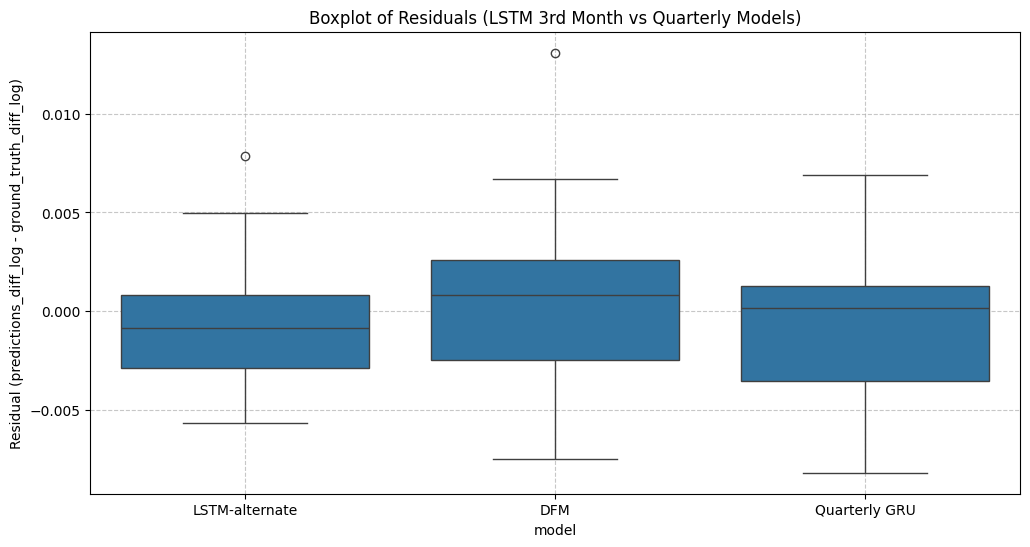

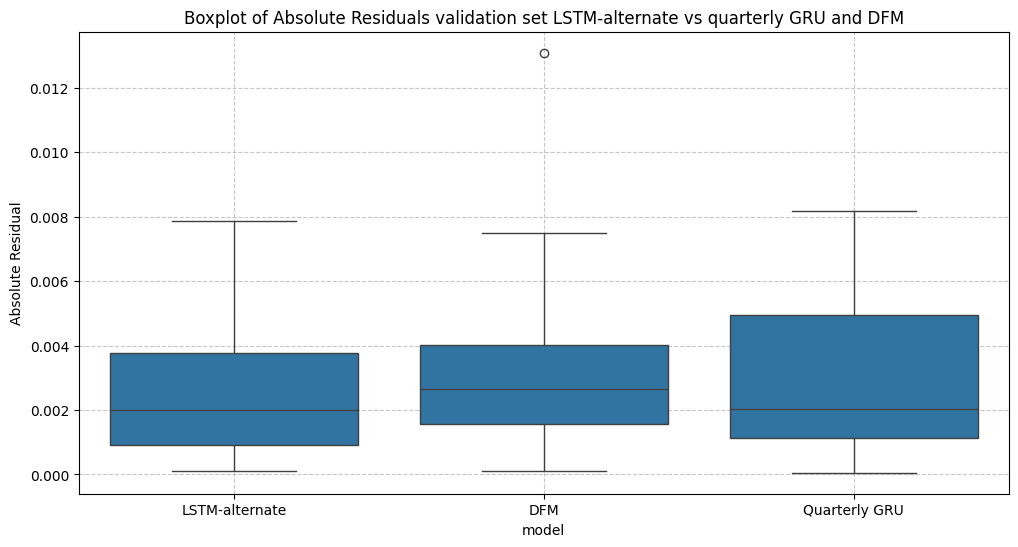

Paired t-test results (3rd month predictions):
LSTM-alternate vs Quarterly GRU: t-stat = -1.2545, p-value = 0.2193
LSTM-alternate vs DFM: t-stat = -1.6444, p-value = 0.1105

Interpretation (α = 0.05):
LSTM-alternate (3rd month) is not significantly different from Quarterly GRU
LSTM-alternate (3rd month) is not significantly different from DFM

Absolute Residual Statistics (3rd Month):
DFM: Mean = 0.0033, Median = 0.0026, Std = 0.0026
LSTM-alternate (3rd Month): Mean = 0.0025, Median = 0.0020, Std = 0.0019
Quarterly GRU: Mean = 0.0031, Median = 0.0020, Std = 0.0026


In [42]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

# Process each dataframe to extract dates and calculate residuals
def prepare_data(df, model_name):
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        
    # Calculate residuals (prediction - ground_truth)
    df['residual'] = df['predictions_diff_log'] - df['ground_truth_diff_log']
    df['abs_residual'] = abs(df['residual'])
    df['model'] = model_name
    
    return df

# Process each dataset
dfm_data = prepare_data(dfm_result_test.copy(), 'DFM')
lstm_alt_data_original = prepare_data(alternate_lstm_result_test.copy(), 'LSTM-alternate')
quarterly_gru_data = prepare_data(quarterly_gru_result_test.copy(), 'Quarterly GRU')

# Filter LSTM alternate dataset to get only 3rd month predictions
# Third months are May, August, November, February (months 5, 8, 11, 2)
third_months = [5, 8, 11, 2]
lstm_alt_data_third = lstm_alt_data_original[lstm_alt_data_original.index.month.isin(third_months)]

# For each third month prediction from LSTM, find the corresponding preceding
# quarter-end date that the quarterly models would have used
lstm_dates = []
quarterly_dates = []

for date in sorted(lstm_alt_data_third.index):
    # May (5) corresponds to March (3)
    if date.month == 5:
        q_date = pd.Timestamp(date.year, 3, 31)
    # August (8) corresponds to June (6)
    elif date.month == 8:
        q_date = pd.Timestamp(date.year, 6, 30)
    # November (11) corresponds to September (9)
    elif date.month == 11:
        q_date = pd.Timestamp(date.year, 9, 30)
    # February (2) corresponds to previous year's December (12)
    elif date.month == 2:
        q_date = pd.Timestamp(date.year-1, 12, 31)
    
    # Adjust to actual dates in DFM and Quarterly GRU datasets
    # Find the closest available date before or at q_date
    dfm_available_dates = [d for d in dfm_data.index if d <= q_date]
    qgru_available_dates = [d for d in quarterly_gru_data.index if d <= q_date]
    
    if dfm_available_dates and qgru_available_dates:
        dfm_closest = max(dfm_available_dates)
        qgru_closest = max(qgru_available_dates)
        
        # Only include if both models have a valid date
        if dfm_closest == qgru_closest:
            lstm_dates.append(date)
            quarterly_dates.append(dfm_closest)

# If we have matching dates
if lstm_dates and quarterly_dates:
    # Get the matched data
    lstm_aligned = lstm_alt_data_third.loc[lstm_dates]
    dfm_aligned = dfm_data.loc[quarterly_dates]
    qgru_aligned = quarterly_gru_data.loc[quarterly_dates]
    
    print(f"Found {len(lstm_dates)} matching date pairs for 3rd month analysis")
    print("LSTM dates:", lstm_dates)
    print("Quarterly model dates:", quarterly_dates)
    
    # Create plotting data with reset indices
    lstm_plot = lstm_aligned.reset_index()
    dfm_plot = dfm_aligned.reset_index()
    qgru_plot = qgru_aligned.reset_index()
    all_data = pd.concat([lstm_plot, dfm_plot, qgru_plot])
    
    # Create boxplots of residuals
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='model', y='residual', data=all_data)
    plt.title('Boxplot of Residuals (LSTM 3rd Month vs Quarterly Models)')
    plt.ylabel('Residual (predictions_diff_log - ground_truth_diff_log)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    # Create boxplots of absolute residuals
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='model', y='abs_residual', data=all_data)
    plt.title('Boxplot of Absolute Residuals validation set LSTM-alternate vs quarterly GRU and DFM') 
    plt.ylabel('Absolute Residual')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    # Perform t-tests
    if len(lstm_aligned) == len(dfm_aligned) == len(qgru_aligned):
        # Test LSTM-alternate 3rd month vs Quarterly GRU
        t_stat_lstm_vs_gru, p_value_lstm_vs_gru = stats.ttest_rel(
            lstm_aligned['abs_residual'].values, 
            qgru_aligned['abs_residual'].values
        )
        
        # Test LSTM-alternate 3rd month vs DFM
        t_stat_lstm_vs_dfm, p_value_lstm_vs_dfm = stats.ttest_rel(
            lstm_aligned['abs_residual'].values, 
            dfm_aligned['abs_residual'].values
        )
        
        # Print results
        print("Paired t-test results (3rd month predictions):")
        print(f"LSTM-alternate vs Quarterly GRU: t-stat = {t_stat_lstm_vs_gru:.4f}, p-value = {p_value_lstm_vs_gru:.4f}")
        print(f"LSTM-alternate vs DFM: t-stat = {t_stat_lstm_vs_dfm:.4f}, p-value = {p_value_lstm_vs_dfm:.4f}")
        
        # Interpretation
        alpha = 0.05
        print("\nInterpretation (α = 0.05):")
        print(f"LSTM-alternate (3rd month) is {'significantly' if p_value_lstm_vs_gru < alpha else 'not significantly'} different from Quarterly GRU")
        print(f"LSTM-alternate (3rd month) is {'significantly' if p_value_lstm_vs_dfm < alpha else 'not significantly'} different from DFM")
        
        # Statistics
        print("\nAbsolute Residual Statistics (3rd Month):")
        models = ['DFM', 'LSTM-alternate (3rd Month)', 'Quarterly GRU']
        abs_residuals = [dfm_aligned['abs_residual'], lstm_aligned['abs_residual'], qgru_aligned['abs_residual']]
        
        for model, res in zip(models, abs_residuals):
            print(f"{model}: Mean = {res.mean():.4f}, Median = {res.median():.4f}, Std = {res.std():.4f}")
    else:
        print("Error: Datasets are not of equal length for paired t-test")
else:
    print("No matching dates found for third month analysis")

In [22]:
# Load test result datasets
dfm_result_val = pd.read_csv("results/loss_plot 2025-05-18 22h03m28s dfm/val idx=0 dfm.csv", parse_dates=['Unnamed: 0'])
alternate_lstm_result_val = pd.read_csv("results/loss_plot 2025-05-18 21h33m36s LSTM-alternate/val idx=2 LSTM-alternate.csv", parse_dates=['Unnamed: 0'])
quarterly_gru_result_val = pd.read_csv("results/loss_plot 2025-05-18 21h34m00s Quarterly GRU/val idx=2 Quarterly GRU.csv", parse_dates=['Unnamed: 0'])

# Set the date column as index
dfm_result_val.set_index('Unnamed: 0', inplace=True)
alternate_lstm_result_val.set_index('Unnamed: 0', inplace=True)
quarterly_gru_result_val.set_index('Unnamed: 0', inplace=True)

# Rename the index for clarity
dfm_result_val.index.name = 'date'
alternate_lstm_result_val.index.name = 'date'
quarterly_gru_result_val.index.name = 'date'

In [ ]:
print (alternate_lstm_result_val)

            predictions_usd  ground_truth_usd  predictions_diff_log  \
date                                                                  
1971-06-01      5492.125814       5473.059000              0.008871   
1971-07-01      5506.116738       5473.059000              0.011416   
1971-08-01      5519.047713       5473.059000              0.013761   
1971-09-01      5566.342515       5518.072000              0.016901   
1971-10-01      5531.856788       5518.072000              0.010686   
...                     ...               ...                   ...   
2011-01-01     16973.831950      16960.864001              0.006002   
2011-02-01     16965.955228      16960.864001              0.005537   
2011-03-01     17022.494013      16920.632008              0.003627   
2011-04-01     17044.852119      16920.632008              0.004940   
2011-05-01     17034.522769      16920.632008              0.004333   

            ground_truth_diff_log  
date                               
1971

In [ ]:
# results\loss_plot 2025-05-19 09h03m34s LSTM-repeat\test idx=2 LSTM-repeat.csv
# results\loss_plot 2025-05-19 09h03m45s LSTM-bilayer\test idx=2 LSTM-bilayer.csv
# results\loss_plot 2025-05-19 09h03m55s LSTM-alternate\test idx=2 LSTM-alternate.csv
# results\loss_plot 2025-05-19 09h04m03s GRU-repeat\test idx=2 GRU-repeat.csv
# results\loss_plot 2025-05-19 09h04m11s GRU-bilayer\test idx=2 GRU-bilayer.csv
# results\loss_plot 2025-05-19 09h04m20s GRU-alternate\test idx=2 GRU-alternate.csv
# results\loss_plot 2025-05-19 09h04m30s Quarterly LSTM\test idx=2 Quarterly LSTM.csv
# results\loss_plot 2025-05-19 09h04m40s Quarterly GRU\test idx=2 Quarterly GRU.csv
# results\loss_plot 2025-05-19 09h04m49s Univariate LSTM\test idx=2 Univariate LSTM.csv
# results\loss_plot 2025-05-19 09h04m49s Univariate LSTM\test idx=2 Univariate LSTM.csv
# results\loss_plot 2025-05-19 09h04m59s Univariate GRU\test idx=2 Univariate GRU.csv
# results\loss_plot 2025-05-19 09h05m09s Quarterly LSTM\test idx=2 Quarterly LSTM.csv
# results\loss_plot 2025-05-19 09h21m03s dfm\test idx=0 dfm.csv
# results\loss_plot 2025-05-19 09h21m06s arima\test idx=0 arima.csv
# results\loss_plot 2025-05-19 09h21m10s arimax\test idx=0 arimax.csv

def load(split):
    dfs = {
        'lstm-repeat': pd.read_csv(f"results/loss_plot 2025-05-19 09h03m34s LSTM-repeat/{split} idx=2 LSTM-repeat.csv", parse_dates=['Unnamed: 0']),
        'lstm-bilayer': pd.read_csv(f"results/loss_plot 2025-05-19 09h03m45s LSTM-bilayer/{split} idx=2 LSTM-bilayer.csv", parse_dates=['Unnamed: 0']),
        'lstm-alternate': pd.read_csv(f"results/loss_plot 2025-05-19 09h03m55s LSTM-alternate/{split} idx=2 LSTM-alternate.csv", parse_dates=['Unnamed: 0']),
        'gru-repeat': pd.read_csv(f"results/loss_plot 2025-05-19 09h04m03s GRU-repeat/{split} idx=2 GRU-repeat.csv", parse_dates=['Unnamed: 0']),
        'gru-bilayer': pd.read_csv(f"results/loss_plot 2025-05-19 09h04m11s GRU-bilayer/{split} idx=2 GRU-bilayer.csv", parse_dates=['Unnamed: 0']),
        'gru-alternate': pd.read_csv(f"results/loss_plot 2025-05-19 09h04m20s GRU-alternate/{split} idx=2 GRU-alternate.csv", parse_dates=['Unnamed: 0']),
        'quarterly-lstm': pd.read_csv(f"results/loss_plot 2025-05-19 09h04m30s Quarterly LSTM/{split} idx=2 Quarterly LSTM.csv", parse_dates=['Unnamed: 0']),
        'quarterly-gru': pd.read_csv(f"results/loss_plot 2025-05-19 09h04m40s Quarterly GRU/{split} idx=2 Quarterly GRU.csv", parse_dates=['Unnamed: 0']),
        'univariate-lstm': pd.read_csv(f"results/loss_plot 2025-05-19 09h04m49s Univariate LSTM/{split} idx=2 Univariate LSTM.csv", parse_dates=['Unnamed: 0']),
        'univariate-gru': pd.read_csv(f"results/loss_plot 2025-05-19 09h04m59s Univariate GRU/{split} idx=2 Univariate GRU.csv", parse_dates=['Unnamed: 0']),
        'quarterly-lstm': pd.read_csv(f"results/loss_plot 2025-05-19 09h04m49s Univariate LSTM/{split} idx=2 Univariate LSTM.csv", parse_dates=['Unnamed: 0']),
        'quarterly-gru': pd.read_csv(f"results/loss_plot 2025-05-19 09h05m09s Quarterly LSTM/{split} idx=2 Quarterly LSTM.csv", parse_dates=['Unnamed: 0']),
        'dfm': pd.read_csv(f"results/loss_plot 2025-05-19 09h21m03s dfm/{split} idx=0 dfm.csv", parse_dates=['Unnamed: 0']),
        'arima': pd.read_csv(f"results/loss_plot 2025-05-19 09h21m06s arima/{split} idx=0 arima.csv", parse_dates=['Unnamed: 0']),
        'arimax': pd.read_csv(f"results/loss_plot 2025-05-19 09h21m10s arimax/{split} idx=0 arimax.csv", parse_dates=['Unnamed: 0']),
    }

    for key, df in dfs.items():
        df.set_index('Unnamed: 0', inplace=True)
        df.index.name = 'date'
    
    return dfs

val_results = load('val')
test_results = load('test')

In [71]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

def metrics_offset(df, offset):
    selected_month = df.index.month.isin([offset + 3, offset + 6, offset + 9, (offset + 11) % 12 + 1])
    selected_rows = df.loc[selected_month]
    return {
        'mae': mean_absolute_error(selected_rows['ground_truth_diff_log'], selected_rows['predictions_diff_log']),
        'rmse': root_mean_squared_error(selected_rows['ground_truth_diff_log'], selected_rows['predictions_diff_log']),
    }

    


In [ ]:
print("LSTM-alternate val stats:")
print(metrics_offset(val_results['lstm-alternate'], 0))
print(metrics_offset(val_results['lstm-alternate'], 1))
print(metrics_offset(val_results['lstm-alternate'], 2))
print()

print("GRU-alternate val stats:")
print(metrics_offset(val_results['gru-alternate'], 0))
print(metrics_offset(val_results['gru-alternate'], 1))
print(metrics_offset(val_results['gru-alternate'], 2))
print()

print("DFM val stats:")
print(metrics_offset(val_results['dfm'], 0))
print(metrics_offset(val_results['dfm'], 1))
print(metrics_offset(val_results['dfm'], 2))
print()

print("Quarterly GRU val stats:")
print(metrics_offset(val_results['quarterly-gru'], 0))

print("Quarterly LSTM val stats:")
print(metrics_offset(val_results['quarterly-lstm'], 0))

print("LSTM-alternate test stats:")
print(metrics_offset(test_results['lstm-alternate'], 0))
print(metrics_offset(test_results['lstm-alternate'], 1))
print(metrics_offset(test_results['lstm-alternate'], 2))
print()

print("GRU-alternate test stats:")
print(metrics_offset(test_results['gru-alternate'], 0))
print(metrics_offset(test_results['gru-alternate'], 1))
print(metrics_offset(test_results['gru-alternate'], 2))
print()

print("DFM test stats:")
print(metrics_offset(test_results['dfm'], 0))
print(metrics_offset(test_results['dfm'], 1))
print(metrics_offset(test_results['dfm'], 2))
print()

print("Quarterly LSTM test stats:")
print(metrics_offset(test_results['quarterly-lstm'], 0))

print("Quarterly GRU test stats:")
print(metrics_offset(test_results['quarterly-gru'], 0))


LSTM-alternate val stats:
{'mae': 0.004649547602688139, 'rmse': 0.005811614283303842}
{'mae': 0.003930214079133081, 'rmse': 0.005226611393876659}
{'mae': 0.003780405232820276, 'rmse': 0.005126909616684474}

GRU-alternate val stats:
{'mae': 0.004176360992290011, 'rmse': 0.005492746560189412}
{'mae': 0.0035299402317926884, 'rmse': 0.004626604198157334}
{'mae': 0.0036800610311403313, 'rmse': 0.004820970977887901}

DFM val stats:
{'mae': 0.005209060801923196, 'rmse': 0.007010345087684376}
{'mae': 0.005711193614023109, 'rmse': 0.007320110216002756}
{'mae': 0.004728710815940951, 'rmse': 0.00620477360645092}

LSTM-alternate test stats:
{'mae': 0.0026506640932243944, 'rmse': 0.00312368659799481}
{'mae': 0.002255222947430332, 'rmse': 0.0029925314242520472}
{'mae': 0.002568273932582326, 'rmse': 0.0031930911590765305}

GRU-alternate test stats:
{'mae': 0.0029326484594333945, 'rmse': 0.0034578134384341025}
{'mae': 0.0024725216020765888, 'rmse': 0.0030217095789986607}
{'mae': 0.0024273718977929778,

In [83]:
def average_over_offsets(df):
    offsets = [0, 1, 2]
    results = {offset: metrics_offset(df, offset) for offset in offsets}
    
    avg_rmse = np.mean([results[offset]['rmse'] for offset in offsets])
    avg_mae = np.mean([results[offset]['mae'] for offset in offsets])
    
    return {
        'avg_mae': avg_mae.item(),
        'avg_rmse': avg_rmse.item(),
    }
ds = {
    'lstm-alternate-val': average_over_offsets(val_results['lstm-alternate']),
    'lstm-alternate-test': average_over_offsets(test_results['lstm-alternate']),
}

for key, d in ds.items():
    print(f"{key}:\tMAE = {d['avg_mae']*1000:.4f}, RMSE = {d['avg_rmse']*100:.4f}")

lstm-alternate-val:	MAE = 4.1201, RMSE = 0.5388
lstm-alternate-test:	MAE = 2.4914, RMSE = 0.3103


In [84]:
mixed_freq_models = [
    'lstm-repeat',
    'gru-repeat',
    'lstm-bilayer',
    'gru-bilayer',
    'lstm-alternate',
    'gru-alternate',
    'dfm',
]

single_freq_models = [
    'quarterly-lstm',
    'quarterly-gru',
    'univariate-lstm',
    'univariate-gru',
    'arima',
    'arimax',
]

In [87]:
print("{")
for model in mixed_freq_models:
    for split, data in [('val', val_results), ('test', test_results)]:
        print(f"  '{model} {split} stats': {{")
        for offset in range(3):
            print(f"    'Offset {offset}': {metrics_offset(data[model], offset)},")
        print("    'Mean':", average_over_offsets(data[model]), ',')
        print("  },")
        print()

for model in single_freq_models:
    for split, data in [('val', val_results), ('test', test_results)]:
        print(f"  '{model} {split} stats': {{")
        print("    'Mean':", metrics_offset(data[model], 0), ',')
        print("  },")
        print()

print("}")

{
  'lstm-repeat val stats': {
    'Offset 0': {'mae': 0.004787958501451418, 'rmse': 0.006125379466255986},
    'Offset 1': {'mae': 0.00402076147885208, 'rmse': 0.005423140645044285},
    'Offset 2': {'mae': 0.004007130649647252, 'rmse': 0.005598735286314309},
    'Mean': {'avg_mae': 0.0042719502099835835, 'avg_rmse': 0.00571575179920486} ,
  },

  'lstm-repeat test stats': {
    'Offset 0': {'mae': 0.002740773461619206, 'rmse': 0.0033831220942565654},
    'Offset 1': {'mae': 0.0027566087480143486, 'rmse': 0.0034161550386335175},
    'Offset 2': {'mae': 0.003016669241976623, 'rmse': 0.003617780458434083},
    'Mean': {'avg_mae': 0.002838017150536726, 'avg_rmse': 0.0034723525304413885} ,
  },

  'gru-repeat val stats': {
    'Offset 0': {'mae': 0.004327311167996768, 'rmse': 0.005655773316745703},
    'Offset 1': {'mae': 0.0036474027913046235, 'rmse': 0.004861927372922876},
    'Offset 2': {'mae': 0.0038431937860695146, 'rmse': 0.005223178054178023},
    'Mean': {'avg_mae': 0.00393930258

C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3230323385.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[df['name'] for df in dfs])


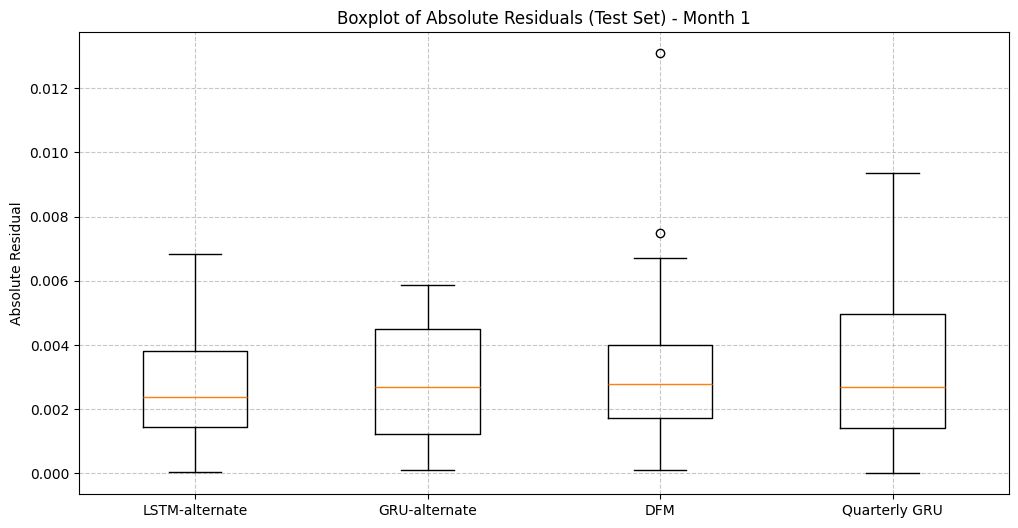

C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3230323385.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[df['name'] for df in dfs])


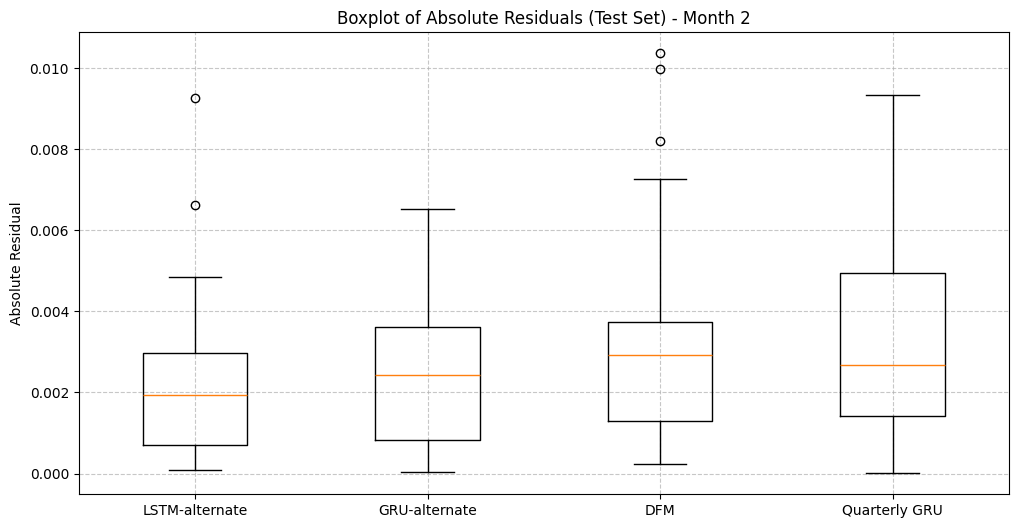

C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3230323385.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[df['name'] for df in dfs])


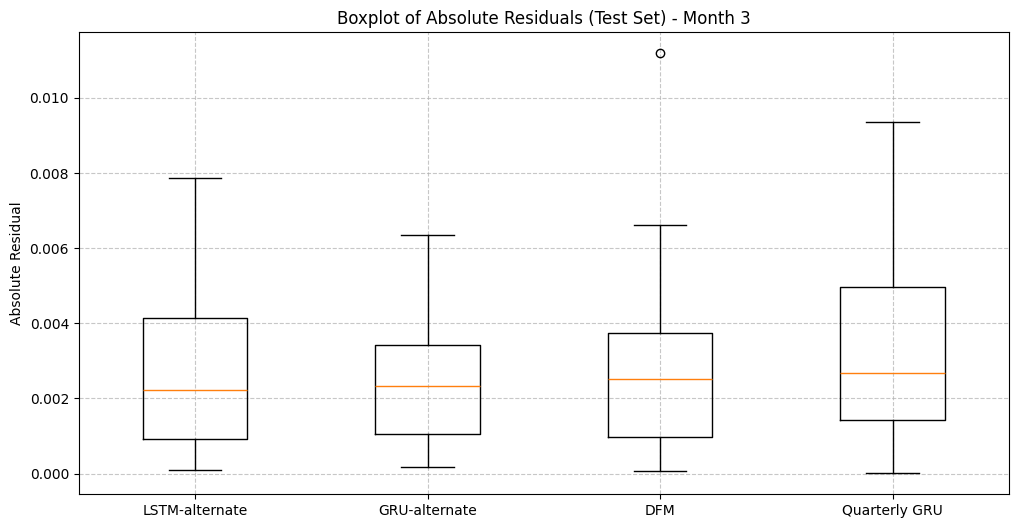

C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3230323385.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[df['name'] for df in dfs])


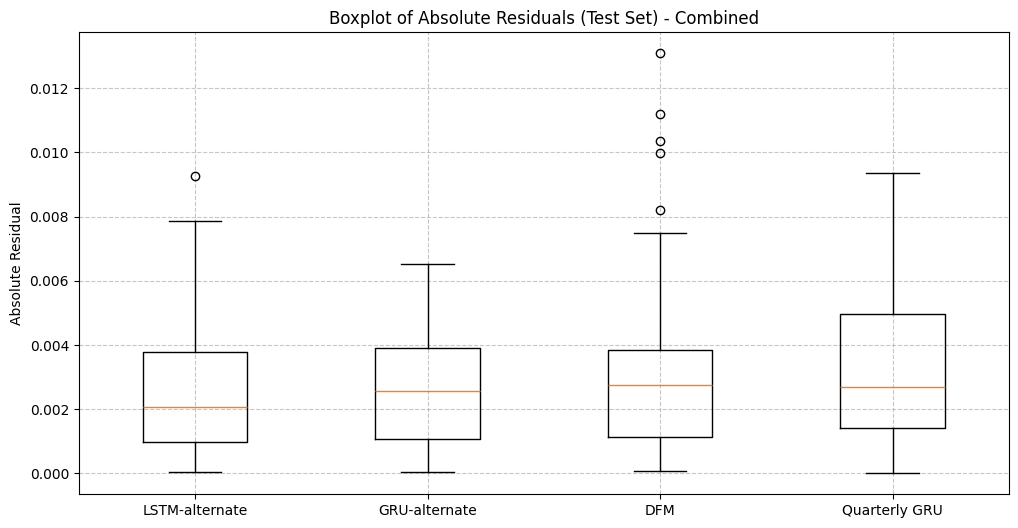

C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3230323385.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[df['name'] for df in dfs])


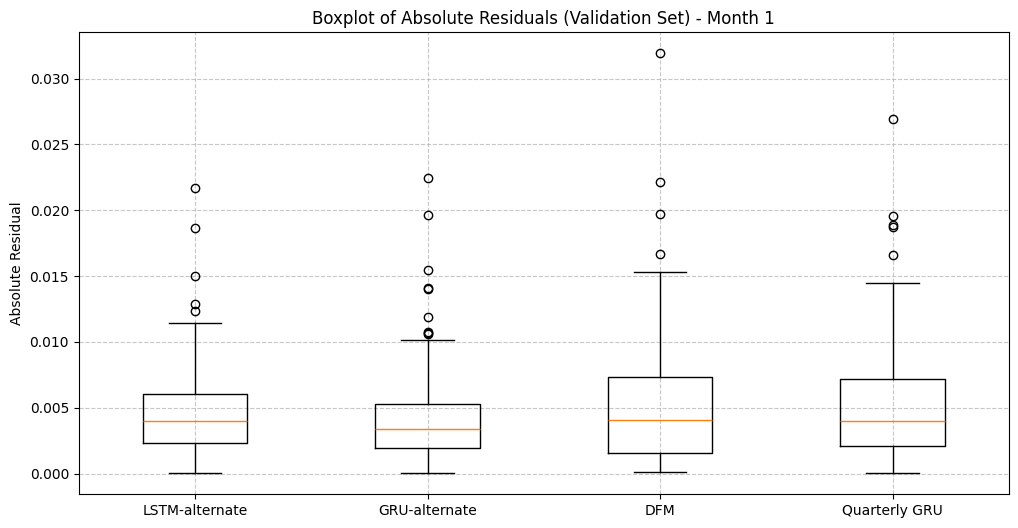

C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3230323385.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[df['name'] for df in dfs])


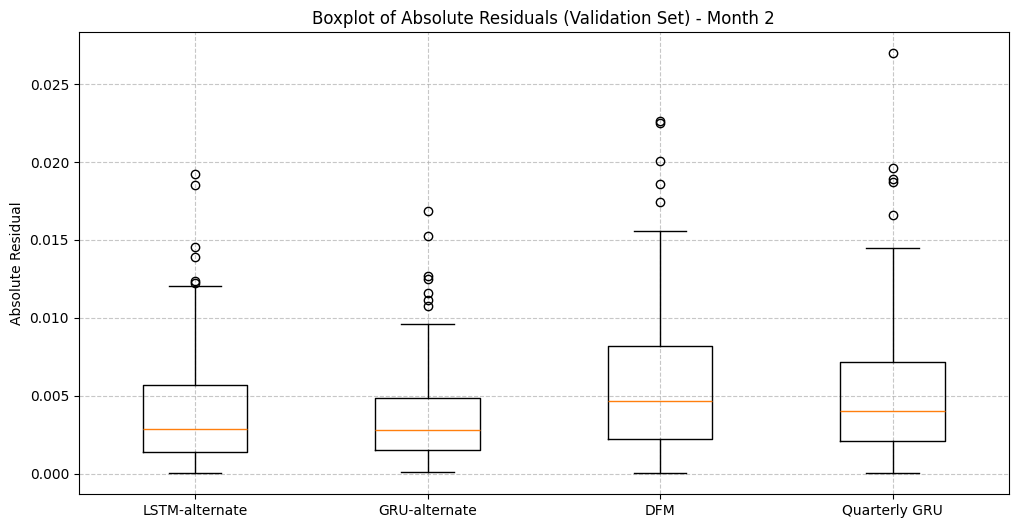

C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3230323385.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[df['name'] for df in dfs])


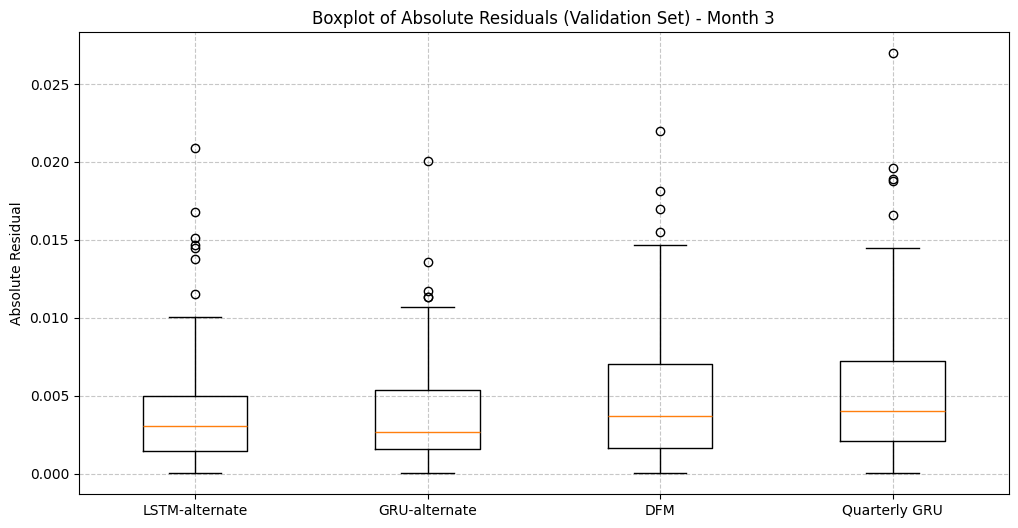

C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3230323385.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[df['name'] for df in dfs])


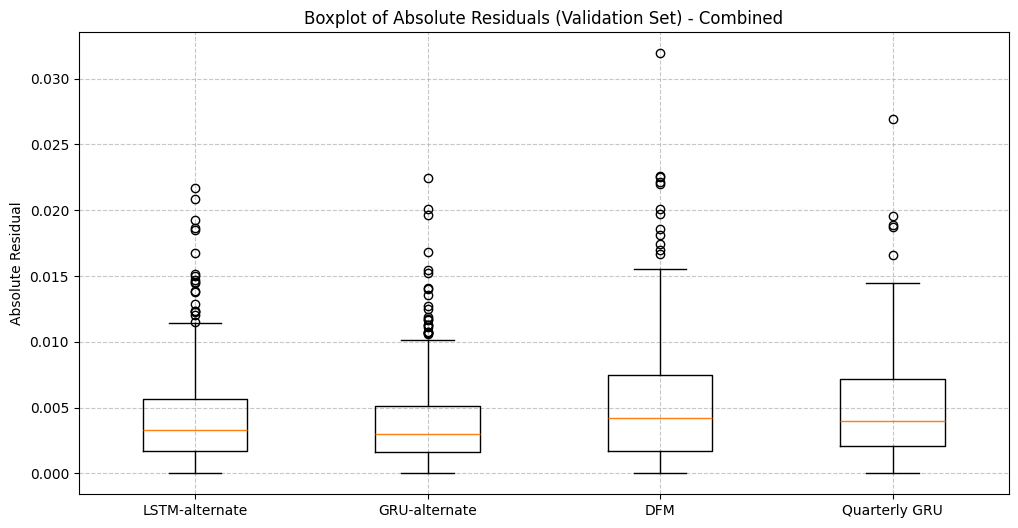

In [101]:
def create_boxplot(dfs, title='Boxplot of Absolute Residuals'):
    plt.figure(figsize=(12, 6))
    data = []
    for df in dfs:
        # calculate absolute residuals because it's not in the dataframe yet
        abs_residuals = abs(df['data']['predictions_diff_log'] - df['data']['ground_truth_diff_log'])
        data.append(abs_residuals)
    
    plt.boxplot(data, labels=[df['name'] for df in dfs])
    plt.title(title)
    plt.ylabel('Absolute Residual')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def months_from_offset(offset):
    if offset == 0:
        return [3, 6, 9, 12]
    elif offset == 1:
        return [4, 7, 10, 1]
    elif offset == 2:
        return [5, 8, 11, 2]

for data, split_name in [(test_results, 'Test'), (val_results, 'Validation')]:
    for offset in range(3):
        valid_months = months_from_offset(offset)

        create_boxplot([
            {'name': 'LSTM-alternate', 'data': data['lstm-alternate'][data['lstm-alternate'].index.month.isin(valid_months)]},
            {'name': 'GRU-alternate', 'data': data['gru-alternate'][data['gru-alternate'].index.month.isin(valid_months)]},
            {'name': 'DFM', 'data': data['dfm'][data['dfm'].index.month.isin(valid_months)]},
            {'name': 'Quarterly GRU', 'data': data['quarterly-gru']},
        ], f"Boxplot of Absolute Residuals ({split_name} Set) - Month {offset + 1}")
    create_boxplot([
        {'name': 'LSTM-alternate', 'data': data['lstm-alternate']},
        {'name': 'GRU-alternate', 'data': data['gru-alternate']},
        {'name': 'DFM', 'data': data['dfm']},
        {'name': 'Quarterly GRU', 'data': data['quarterly-gru']},
    ], f"Boxplot of Absolute Residuals ({split_name} Set) - Combined")


--------- Processing Test set ---------

0 2 0
shapes before: (35, 4) (35, 4)
shapes after: (35, 4) (35, 4)
T-test between LSTM-alternate and DFM (Offset 0): t-stat = -1.5056, p-value = 0.1414
0 3 0
shapes before: (35, 4) (35, 4)
shapes after: (35, 4) (35, 4)
T-test between LSTM-alternate and Quarterly GRU (Offset 0): t-stat = -2.0744, p-value = 0.0457
1 2 0
shapes before: (35, 4) (35, 4)
shapes after: (35, 4) (35, 4)
T-test between GRU-alternate and DFM (Offset 0): t-stat = -0.8149, p-value = 0.4208
1 3 0
shapes before: (35, 4) (35, 4)
shapes after: (35, 4) (35, 4)
T-test between GRU-alternate and Quarterly GRU (Offset 0): t-stat = -0.9089, p-value = 0.3698
0 2 1
shapes before: (35, 4) (35, 4)
shapes after: (35, 4) (35, 4)
T-test between LSTM-alternate and DFM (Offset 1): t-stat = -2.1040, p-value = 0.0429
0 3 1
shapes before: (35, 4) (35, 4)
shapes after: (35, 4) (35, 4)
T-test between LSTM-alternate and Quarterly GRU (Offset 1): t-stat = -2.4855, p-value = 0.0180
1 2 1
shapes befor

C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3045161298.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3045161298.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3045161298.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
C:\Users\giada\AppData\Local\Temp\ipykernel_24760\3045161298.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

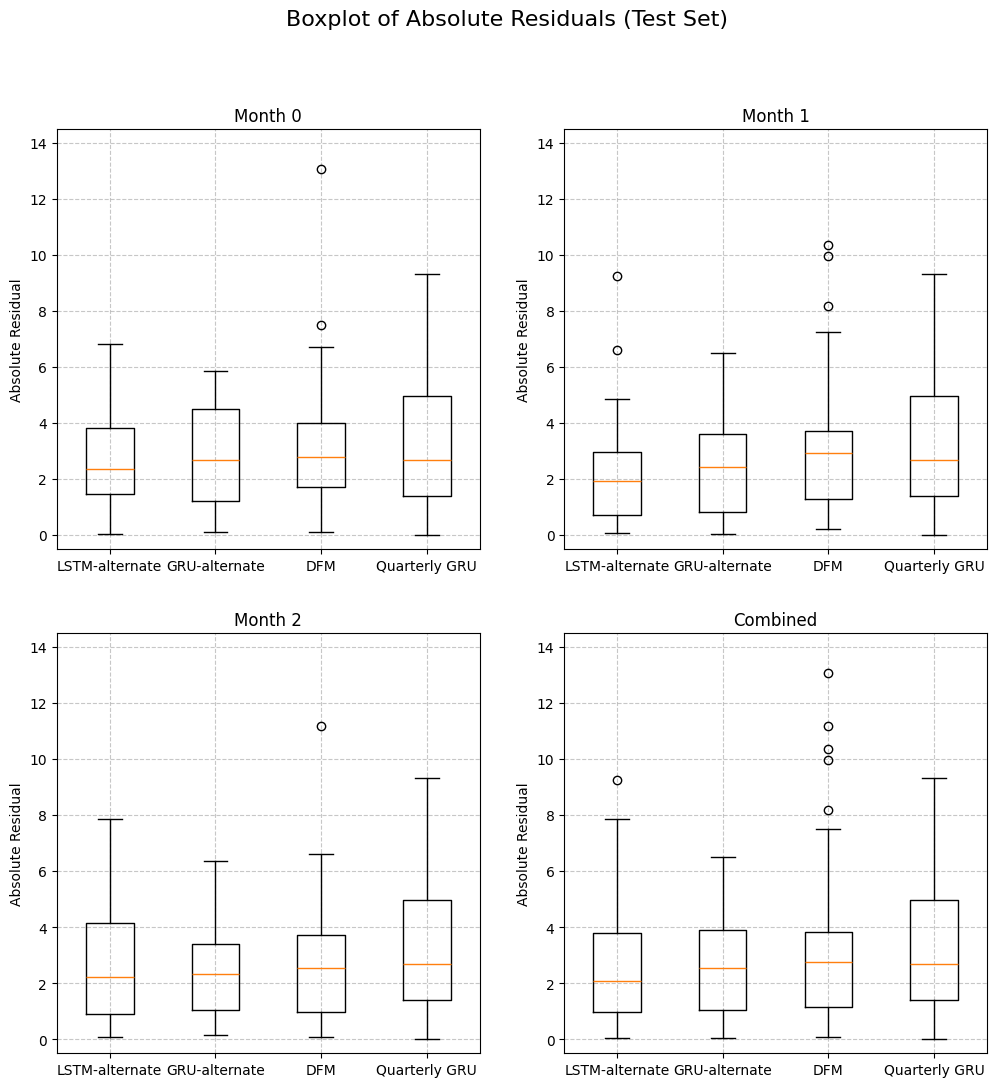

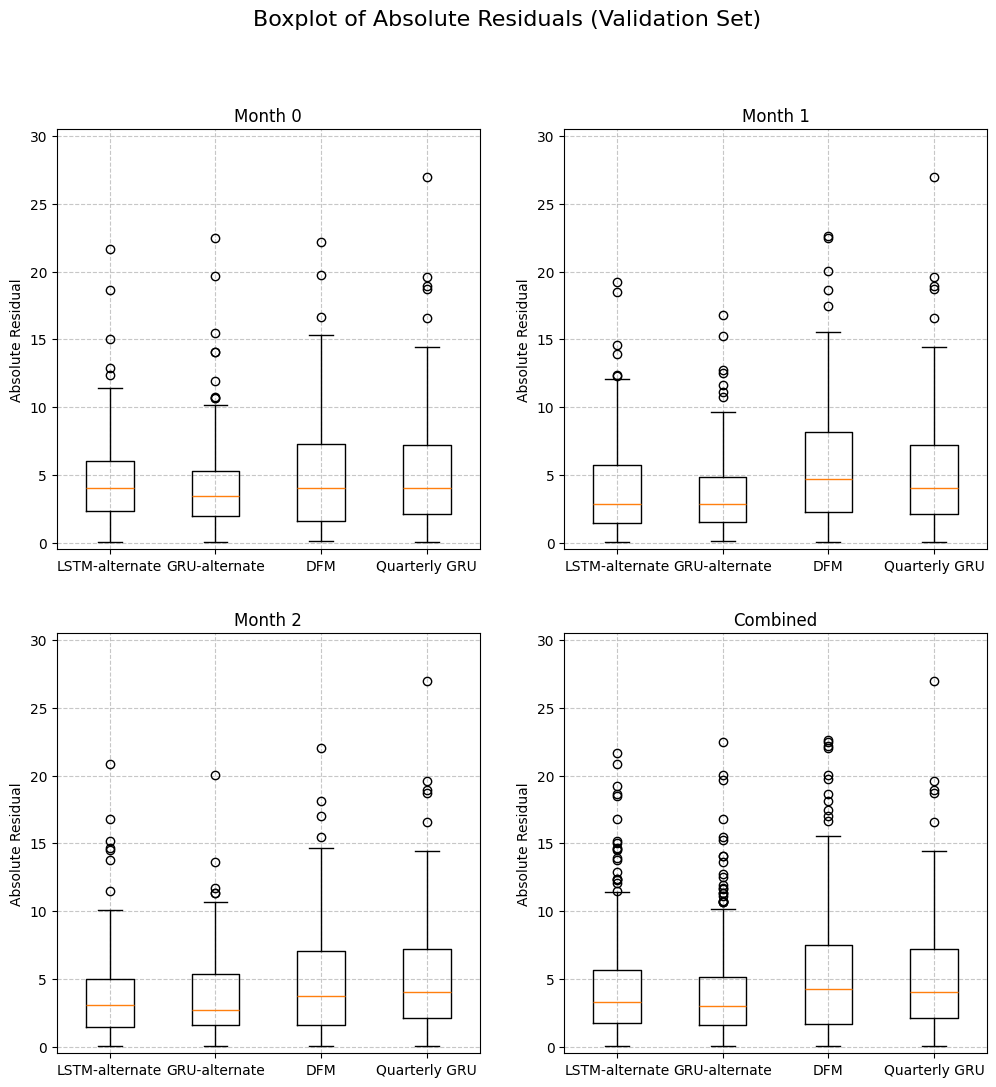

In [130]:
def create_boxplot(dfs, ax, max_ylim=15, title='Boxplot of Absolute Residuals'):
    data = []
    labels = []
    for df in dfs:
        # calculate absolute residuals because it's not in the dataframe yet
        abs_residuals = abs(df['data']['predictions_diff_log'] - df['data']['ground_truth_diff_log']) * 1000
        data.append(abs_residuals)
        labels.append(df['name'])
    
    ax.boxplot(data, labels=labels)
    ax.set_ylim(-0.5, max_ylim)
    ax.set_title(title)
    ax.set_ylabel('Absolute Residual')
    ax.grid(True, linestyle='--', alpha=0.7)
    return ax

def months_from_offset(offset):
    if offset == 0:
        return [3, 6, 9, 12]
    elif offset == 1:
        return [4, 7, 10, 1]
    elif offset == 2:
        return [5, 8, 11, 2]
    
def t_test(dfs, offset):
    for i in [0, 1]:
        for j in [2, 3]:
            print(i, j, offset)
            df_i = dfs[i]['data']
            df_j = dfs[j]['data']

            if offset is not None and j == 3:
               df_i.index = df_i.index - pd.DateOffset(months=offset)
            elif offset is None and j == 3:
                # repeat df_j three times to match the length of df_i
                df_j = pd.concat([df_j] * 3, ignore_index=True)
                df_j.index = df_i.index

            print("shapes before:", df_i.shape, df_j.shape)
            # filter dates not present in both dataframes
            common_dates = df_i.index.intersection(df_j.index)
            df_i = df_i.loc[common_dates]
            df_j = df_j.loc[common_dates]
            print("shapes after:", df_i.shape, df_j.shape)

            abs_residual_i = abs(df_i['predictions_diff_log'] - df_i['ground_truth_diff_log'])
            abs_residual_j = abs(df_j['predictions_diff_log'] - df_j['ground_truth_diff_log'])

            t_stat, p_value = stats.ttest_rel(
                abs_residual_i,
                abs_residual_j,
            )
            print(f"T-test between {dfs[i]['name']} and {dfs[j]['name']} (Offset {offset}): t-stat = {t_stat:.4f}, p-value = {p_value:.4f}")

for data, split_name in [(test_results, 'Test'), (val_results, 'Validation')]:
    print("\n--------- Processing", split_name, "set", "---------\n")
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 12))
    fig.suptitle(f"Boxplot of Absolute Residuals ({split_name} Set)", fontsize=16)
    axs = axs.flatten()
    max_ylim = 14.5 if split_name == 'Test' else 30.5

    for offset in range(3):
        valid_months = months_from_offset(offset)

        dfs = [
            {'name': 'LSTM-alternate', 'data': data['lstm-alternate'][data['lstm-alternate'].index.month.isin(valid_months)]},
            {'name': 'GRU-alternate', 'data': data['gru-alternate'][data['gru-alternate'].index.month.isin(valid_months)]},
            {'name': 'DFM', 'data': data['dfm'][data['dfm'].index.month.isin(valid_months)]},
            {'name': 'Quarterly GRU', 'data': data['quarterly-gru']},
        ]
        
        create_boxplot(dfs, axs[offset], max_ylim, f"Month {offset}")
        t_test(dfs, offset)

    
    dfs = [
        {'name': 'LSTM-alternate', 'data': data['lstm-alternate']},
        {'name': 'GRU-alternate', 'data': data['gru-alternate']},
        {'name': 'DFM', 'data': data['dfm']},
        {'name': 'Quarterly GRU', 'data': data['quarterly-gru']},
    ]
    
    create_boxplot(dfs, axs[-1], max_ylim, f"Combined")
    t_test(dfs, None)

In [137]:
# calculate rmse and  mae for every model:
print("{")

for model in mixed_freq_models:
    for split, data in [('val', val_results), ('test', test_results)]:
        print(f"  '{model} {split} stats': {{")
        # for offset in range(3):
        #     print(f"    'Offset {offset}': {metrics_offset(data[model], offset)},")
        print("    'Mean':", average_over_offsets(data[model]), ',')
        print("  },")
        print()

for model in single_freq_models:
    for split, data in [('val', val_results), ('test', test_results)]:
        print(f"  '{model} {split} stats': {{")
        print("    'Mean':", metrics_offset(data[model], 0), ',')
        print("  },")
        print()

print("}")

{
  'lstm-repeat val stats': {
    'Mean': {'avg_mae': 0.0042719502099835835, 'avg_rmse': 0.00571575179920486} ,
  },

  'lstm-repeat test stats': {
    'Mean': {'avg_mae': 0.002838017150536726, 'avg_rmse': 0.0034723525304413885} ,
  },

  'gru-repeat val stats': {
    'Mean': {'avg_mae': 0.003939302581790302, 'avg_rmse': 0.005246959581282201} ,
  },

  'gru-repeat test stats': {
    'Mean': {'avg_mae': 0.00274543309499344, 'avg_rmse': 0.0032774724069141} ,
  },

  'lstm-bilayer val stats': {
    'Mean': {'avg_mae': 0.004439538393394858, 'avg_rmse': 0.005817118764504556} ,
  },

  'lstm-bilayer test stats': {
    'Mean': {'avg_mae': 0.002757222683978341, 'avg_rmse': 0.003436209794678114} ,
  },

  'gru-bilayer val stats': {
    'Mean': {'avg_mae': 0.004010539332114073, 'avg_rmse': 0.005332151780086912} ,
  },

  'gru-bilayer test stats': {
    'Mean': {'avg_mae': 0.0028695347154796495, 'avg_rmse': 0.0035194334926543186} ,
  },

  'lstm-alternate val stats': {
    'Mean': {'avg_mae': 0.